<a href="https://colab.research.google.com/github/maramgueye/projetfairness/blob/main/projet_fairness_Gueye_Ifkharen_Guellal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Projet Fairness – Détection de pathologies pulmonaires**
## Chest X-Ray NIH 14 – Analyse de biais et mitigation

Par Maram Sall GUEYE, Malak Ifkharen et Sofia Guellal  
**Université Paris-Saclay – Thales**


## Introduction

Les modèles de machine learning appliqués au domaine médical peuvent amplifier des biais présents dans les données d'entraînement. Dans ce projet, nous analysons un sous-ensemble du dataset Chest X-Ray NIH 14, qui contient des radiographies thoraciques annotées avec des métadonnées (âge, genre, position de vue).

Nous étudions :
1. Les déséquilibres et biais présents dans les données
2. L'impact du pre-processing (pondération des exemples) sur l'équité du modèle
3. L'impact du post-processing (ajustement des seuils) sur l'équité du modèle

# DEBUT DU PROJET

1.1 Installation

In [109]:
# To execute only in Colab
! python -m pip install numpy fairlearn plotly nbformat ipykernel aif360["inFairness"] aif360['AdversarialDebiasing'] causal-learn BlackBoxAuditing cvxpy dice-ml lime shapkit

In [110]:

# Code to compute fairness metrics using aif360
#Fonction issus des TD

from aif360.sklearn.metrics import *
from sklearn.metrics import balanced_accuracy_score, confusion_matrix


def get_metrics(
    y_true, # list or np.array of truth values
    y_pred=None,  # list or np.array of predictions
    prot_attr=None, # list or np.array of protected/sensitive attribute values
    priv_group=1, # value taken by the privileged group
    pos_label=1, # value taken by the positive truth/prediction
    sample_weight=None # list or np.array of weights value,
):
    group_metrics = {}
    group_metrics["base_rate_truth"] = base_rate(
        y_true=y_true, pos_label=pos_label, sample_weight=sample_weight
    )
    group_metrics["statistical_parity_difference"] = statistical_parity_difference(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
    )
    group_metrics["disparate_impact_ratio"] = disparate_impact_ratio(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
    )
    if not y_pred is None:
        group_metrics["base_rate_preds"] = base_rate(
        y_true=y_pred, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["equal_opportunity_difference"] = equal_opportunity_difference(
            y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["average_odds_difference"] = average_odds_difference(
            y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
        )
        if len(set(y_pred))>1:
            group_metrics["conditional_demographic_disparity"] = conditional_demographic_disparity(
                y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, pos_label=pos_label, sample_weight=sample_weight
            )
        else:
            group_metrics["conditional_demographic_disparity"] =None
        group_metrics["smoothed_edf"] = smoothed_edf(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["df_bias_amplification"] = df_bias_amplification(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["balanced_accuracy_score"] = balanced_accuracy_score(
        y_true=y_true, y_pred=y_pred, sample_weight=sample_weight
        )
    return group_metrics


In [111]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix

### Preparation des donnees

### 1.1 Chargement des donnees du git

In [112]:
import sys, os
!git clone https://github.com/maramgueye/projetfairness.git /content/projetfairness
!git clone https://github.com/maramgueye/test123.git /content/test123

fatal: destination path '/content/projetfairness' already exists and is not an empty directory.
fatal: destination path '/content/test123' already exists and is not an empty directory.


In [113]:
#df = pd.read_csv(CSV_PATH)


df = pd.read_csv("/content/projetfairness/Gueye_Maram_Sall/metadata.csv")

print(f"Shape : {df.shape}")
print("Données chargées:", len(df),"échantillons")
print("Colonnes:", list(df.columns))
print("\nAperçu des données:")
df.head(10)

Shape : (4952, 15)
Données chargées: 4952 échantillons
Colonnes: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11', 'train_valid', 'label', 'WEIGHTS']

Aperçu des données:


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,train_valid,label,WEIGHTS
0,00000011_000.png,Effusion,0,11,75,M,PA,2638,2449,0.143,0.143,NaN,train,malade,1
1,00000011_001.png,No Finding,1,11,75,M,PA,2500,2048,0.168,0.168,NaN,train,sain,1
2,00000011_002.png,No Finding,2,11,75,M,PA,2714,2781,0.143,0.143,NaN,train,sain,1
3,00000011_003.png,No Finding,3,11,75,M,PA,2500,2048,0.168,0.168,NaN,train,sain,1
4,00000011_004.png,No Finding,4,11,75,M,PA,2500,2048,0.168,0.168,NaN,train,sain,1
5,00000011_005.png,Infiltration,5,11,75,M,AP,2500,2048,0.168,0.168,NaN,train,malade,1
6,00000011_006.png,Atelectasis,6,11,75,M,PA,2992,2991,0.143,0.143,NaN,train,malade,1
7,00000011_007.png,Infiltration,7,11,75,M,PA,2782,2753,0.143,0.143,NaN,train,malade,1
8,00000011_008.png,No Finding,8,11,75,M,PA,2826,2685,0.143,0.143,NaN,train,sain,1
9,00000016_000.png,No Finding,0,16,71,M,PA,2992,2991,0.143,0.143,NaN,train,sain,1


### Informations générales sur le dataset

In [114]:
print("Nombre total d'échantillons/images:",len(df))
print("Nombre de colonnes:",len(df.columns))
print(f"Train : {len(df[df['train_valid']=='train'])}")
print(f"Valid  : {len(df[df['train_valid']=='valid'])}")
print("\nTypes des données:")
print(df.dtypes)
print("\nValeurs manquantes:")
print(df.isnull().sum())
print("\nDescription:")
df.describe()

Nombre total d'échantillons/images: 4952
Nombre de colonnes: 15
Train : 3799
Valid  : 1153

Types des données:
Image Index                     object
Finding Labels                  object
Follow-up #                      int64
Patient ID                       int64
Patient Age                      int64
Patient Gender                  object
View Position                   object
OriginalImage[Width              int64
Height]                          int64
OriginalImagePixelSpacing[x    float64
y]                             float64
Unnamed: 11                    float64
train_valid                     object
label                           object
WEIGHTS                          int64
dtype: object

Valeurs manquantes:
Image Index                       0
Finding Labels                    0
Follow-up #                       0
Patient ID                        0
Patient Age                       0
Patient Gender                    0
View Position                     0
OriginalImage[Wid

,Follow-up #,Patient ID,Patient Age,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,WEIGHTS
count,4952.000000,4952.000000,4952.000000,4952.000000,4952.000000,4952.000000,4952.000000,0.0,4952.0
mean,6.709410,15003.986874,47.042609,2650.479806,2507.307754,0.155261,0.155261,NaN,1.0
std,11.555045,8341.295062,17.647929,345.970234,399.596469,0.016337,0.016337,NaN,0.0
min,0.000000,11.000000,1.000000,1560.000000,1513.000000,0.139000,0.139000,NaN,1.0
25%,0.000000,8062.000000,34.000000,2500.000000,2048.000000,0.143000,0.143000,NaN,1.0
50%,2.000000,15147.000000,48.000000,2544.000000,2544.000000,0.143000,0.143000,NaN,1.0
75%,8.000000,20900.000000,60.000000,2992.000000,2991.000000,0.168000,0.168000,NaN,1.0
max,90.000000,30802.000000,411.000000,3451.000000,3056.000000,0.198800,0.198800,NaN,1.0


## Nettoyage et Préparation des Données

1.1 Nettoyage âges aberrants

In [115]:
print("\n1. Analyse de l'âge:")
print("   - Min:", df['Patient Age'].min())
print("   - Max:", df['Patient Age'].max())
print("   - Moyenne:", df['Patient Age'].mean())
print("   - Médiane:", df['Patient Age'].median())


1. Analyse de l'âge:
   - Min: 1
   - Max: 411
   - Moyenne: 47.042609046849755
   - Médiane: 48.0


En observant la distribution de Patient Age, on constate un maximum de 414 ans, biologiquement impossible car Ethel Caterham, la doyenne de l'humanité, vient de fêter ses 116 ans !

Nous allons donc filtrer les âges aberrants et fixer une limite d'âge à 120 ans. L'âge minimal n'a pas besoin d'être changé, car nous voyons bien que 1 an est un âge classique.

In [116]:
#ages aberrants (même traitement que le mi-projet)
print("Avant nettoyage :", len(df))
df_clean = df[df['Patient Age'] <= 120].copy()
print("Après nettoyage :", len(df_clean))
print(f"Lignes supprimées : {df.shape[0] - len(df_clean)}")


Avant nettoyage : 4952
Après nettoyage : 4951
Lignes supprimées : 1


2.2 Valeurs manquantes

In [117]:
print(f"\nValeurs manquantes :\n{df_clean.isnull().sum()}")


Valeurs manquantes :
Image Index                       0
Finding Labels                    0
Follow-up #                       0
Patient ID                        0
Patient Age                       0
Patient Gender                    0
View Position                     0
OriginalImage[Width               0
Height]                           0
OriginalImagePixelSpacing[x       0
y]                                0
Unnamed: 11                    4951
train_valid                       0
label                             0
WEIGHTS                           0
dtype: int64


nous constatons que pour Unnamed il y a 4951 valeurs manquantes ce qui representent l'ensembled de notre jeu de donnees.


### 3. Doublons liés au Patient ID

Comme nous l'avions souligner durant le mi-projet, dans le jeu de données NIH Chest X-Ray, chaque ligne correspond à une radiographie et non à un patient, ce qui n'est pas idéal pour une analyse. Un même patient peut avoir effectué plusieurs visites au cours du temps (ce que nous pouvons constater dans la colonne "Follow-up#" ), et donc apparaître plusieurs fois dans le jeu de données avec le même identifiant de patient.
Problème : si on compte les radiographies et non les patients, les individus avec beaucoup de visites (souvent les plus malades et les plus âgés) sont sur-représentés. Cela fausse toute notre analyse descriptive et nos métriques de fairness.

### Visualisation du problème

In [118]:
n_lignes   = len(df_clean)
n_patients = df_clean['Patient ID'].nunique()
print(f'Nombre de lignes dans notre dataset/nbre de radiographies : {n_lignes}')
print(f'Nombre de patients uniques       : {n_patients}')
print(f'Patients avec present plusieurs fois dans notre dataset   : {(df_clean["Patient ID"].value_counts() > 1).sum()}')

Nombre de lignes dans notre dataset/nbre de radiographies : 4951
Nombre de patients uniques       : 1500
Patients avec present plusieurs fois dans notre dataset   : 617


### Nombre de visites par patient


In [119]:
visits_per_patient = df_clean['Patient ID'].value_counts()
print(f'\nDistribution du nombre de visites par patient :')
print(visits_per_patient.value_counts().sort_index().head(10))
print(f'Maximum de visites pour un patient : {visits_per_patient.max()}')


Distribution du nombre de visites par patient :
count
1     883
2     208
3      96
4      66
5      32
6      29
7      23
8      27
9      14
10     13
Name: count, dtype: int64
Maximum de visites pour un patient : 91


### **Contrairement au mi-projet, nous gardons toutes les lignes**

Dans le mi-projet, nous avions conservé une seule ligne par patient car nous analysions les biais au niveau patient.

Ici, la logique est différente car le modèle ResNet18 s'entraîne sur
les images individuelles. Chaque radiographie est un exemple
d'entraînement indépendant, même si elle provient du même patient.
Supprimer des images reviendrait à appauvrir inutilement le dataset.

Nous conservons donc toutes les lignes, soit une par image.

ATTENTION: Cela introduit un biais potentiel : les patients avec beaucoup
de visites (souvent les plus malades) sont plus représentés.
C'est précisément l'un des biais que nous cherchons à corriger
via le pre-processing (pondération).

### Encodage

Pour l'encodage, nous allons suivre l'exemple donner sur les infos RESNES18

D'abord pour le genre

In [120]:
df_clean['gender_bin'] = (df_clean['Patient Gender'] == 'M').astype(int)

Puis, pour savoir si le patient est malade

In [121]:
df_clean['label_bin']  = (df_clean['label'] == 'malade').astype(int)

Apres, le View Position

In [122]:
df_clean['view_bin']   = (df_clean['View Position'] == 'AP').astype(int)

Ensin pour le groupe d'age

In [123]:
df_clean['age_group']  = pd.cut(df_clean['Patient Age'], bins=[0, 40, 60, 120], labels=['<40 ans', '40-60 ans', '>60 ans'])

In [124]:
print("Colonnes créées :")
print("  label_bin  : 0=sain, 1=malade")
print("  gender_bin : 0=F, 1=M")
print("  view_bin   : 0=PA, 1=AP")
print("  age_group  : <40 / 40-60 / >60 ans")
print(f"\nSplit train/valid :")
print(df_clean['train_valid'].value_counts())

Colonnes créées :
  label_bin  : 0=sain, 1=malade
  gender_bin : 0=F, 1=M
  view_bin   : 0=PA, 1=AP
  age_group  : <40 / 40-60 / >60 ans

Split train/valid :
train_valid
train    3798
valid    1153
Name: count, dtype: int64


In [125]:
!ls /content/drive/MyDrive/coursFairness/

ls: cannot access '/content/drive/MyDrive/coursFairness/': No such file or directory




---


# ANALYSE DESCRIPTIVE ET DÉTECTION DES BIAIS

---



Dans cette section, nous allons explorer les données pour comprendre leur structure et,
surtout, identifier d'éventuels biais dans les attributs sensibles (genre, âge, position de vue).

**Pourquoi cette analyse est cruciale ?**

Un biais dans les données d'entraînement peut être amplifié par un modèle d'IA,
conduisant à des prédictions moins fiables pour certaines sous-populations.
Identifier ces biais est la première étape pour les corriger.

**Métriques utilisées :**
- **DPD (Demographic Parity Difference)** :
 Différence de taux de prédiction positive
  entre groupes. Plus proche de 0, mieux c'est.
- **DI (Disparate Impact)** :
Ratio des taux de prédiction positive entre groupes.
  Idéalement proche de 1.
- **Test du Chi-2** : Vérifie si l'association entre attribut sensible et maladie
  est statistiquement significative (p < 0.05).




---






---


#  Analyse de la variable cible


---



La variable cible indique si un patient est malade (1) ou sain (0).
Cette distribution nous donne une idée du déséquilibre initial des classes.


 Distribution des classes :
  - Sains (0) : 2715 radiographies (54.8%)
  - Malades (1): 2236 radiographies (45.2%)


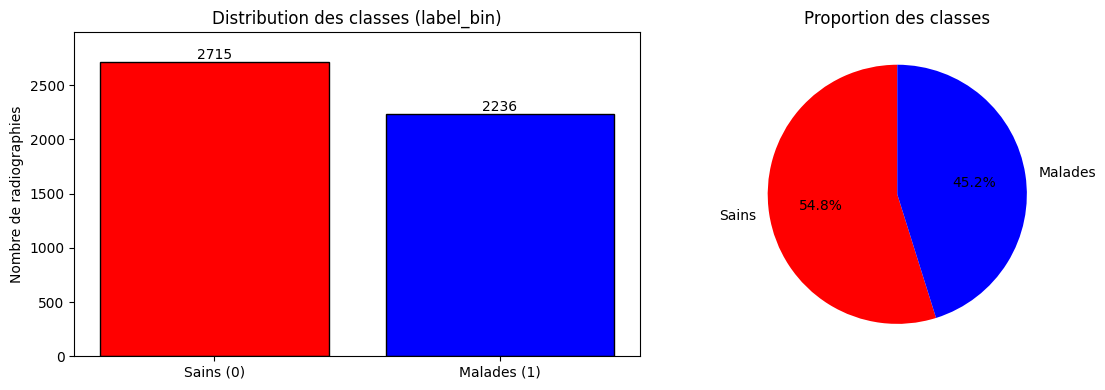

In [126]:
# icii les distribution des classes
disease_counts = df_clean['label_bin'].value_counts()
disease_percent = df_clean['label_bin'].value_counts(normalize=True) * 100


print(f"\n Distribution des classes :")
print(f"  - Sains (0) : {disease_counts.get(0, 0)} radiographies ({disease_percent.get(0, 0):.1f}%)")
print(f"  - Malades (1): {disease_counts.get(1, 0)} radiographies ({disease_percent.get(1, 0):.1f}%)")

# Visualiseer
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barplot
bars = axes[0].bar(['Sains (0)', 'Malades (1)'], disease_counts.values,
                   color=['red', 'blue'], edgecolor='black')
axes[0].set_ylabel('Nombre de radiographies')
axes[0].set_title('Distribution des classes (label_bin)')
axes[0].set_ylim(0, max(disease_counts) * 1.1)

for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}', ha='center', va='bottom')
axes[1].pie(disease_counts.values, labels=['Sains', 'Malades'],
            autopct='%1.1f%%', colors=['red', 'blue'], startangle=90)
axes[1].set_title('Proportion des classes')

plt.tight_layout()
plt.show()



---
**Interprétation :**
- Le dataset contient environ 45.2% de patients malades et 54.8% de patients sains.
- Un léger déséquilibre peut influencer les prédictions du modèle.
- Les méthodes de reweighting que nous appliquerons plus tard pourront
  compenser ce déséquilibre.


---





#**ANALYSE UNIVARIÉE - VARIABLES DÉMOGRAPHIQUES**

---




Analyse univariée des variables démographiques


> Nous examinons la distribution des attributs sensibles qui pourraient introduire
des biais dans les prédictions : le genre, l'âge et la position de vue.

1. Genre (gender_bin)

In [127]:
gender_counts = df_clean['gender_bin'].value_counts()
gender_percent = df_clean['gender_bin'].value_counts(normalize=True) * 100

print(f"  Femmes (0): {gender_counts.get(0, 0)} radiographies ({gender_percent.get(0, 0):.1f}%)")
print(f"  Hommes (1) : {gender_counts.get(1, 0)} radiographies ({gender_percent.get(1, 0):.1f}%)")

  Femmes (0): 2184 radiographies (44.1%)
  Hommes (1) : 2767 radiographies (55.9%)


2. Âge (age_group)

In [128]:
age_counts = df_clean['age_group'].value_counts().sort_index()
age_percent = df_clean['age_group'].value_counts(normalize=True).sort_index() * 100


In [129]:
for group in age_counts.index:
    print(f"  {group}: {age_counts[group]} radiographies ({age_percent[group]:.1f}%)")

  <40 ans: 1711 radiographies (34.6%)
  40-60 ans: 2046 radiographies (41.3%)
  >60 ans: 1194 radiographies (24.1%)


3. Position de vue (view_bin)

In [130]:
print("(0 = PA - Postéro-antérieure, 1 = AP - Antéro-postérieure)")

view_counts = df_clean['view_bin'].value_counts()
view_percent = df_clean['view_bin'].value_counts(normalize=True) * 100

print(f"  PA (0): {view_counts.get(0, 0)} radiographies ({view_percent.get(0, 0):.1f}%)")
print(f"  AP (1) : {view_counts.get(1, 0)} radiographies ({view_percent.get(1, 0):.1f}%)")

(0 = PA - Postéro-antérieure, 1 = AP - Antéro-postérieure)
  PA (0): 3163 radiographies (63.9%)
  AP (1) : 1788 radiographies (36.1%)


**Visualisation des distributions**

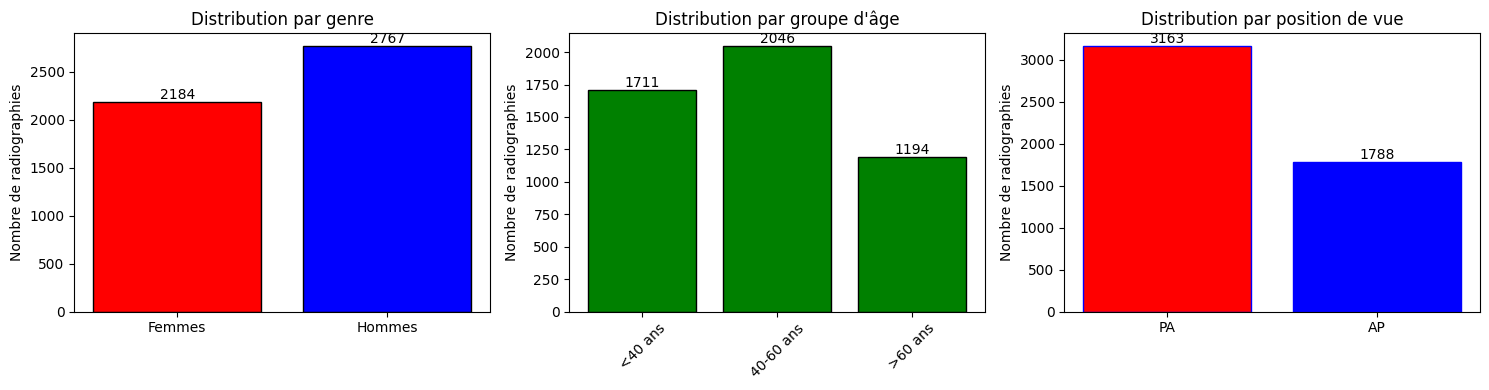

In [131]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Genre
bars1 = axes[0].bar(['Femmes', 'Hommes'], [gender_counts[0], gender_counts[1]],
                    color=['red', 'blue'], edgecolor='black')
axes[0].set_ylabel('Nombre de radiographies')
axes[0].set_title('Distribution par genre')
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                 f'{int(bar.get_height())}', ha='center', va='bottom')

# Âge
bars2 = axes[1].bar(age_counts.index, age_counts.values,
                    color='green', edgecolor='black')
axes[1].set_ylabel('Nombre de radiographies')
axes[1].set_title('Distribution par groupe d\'âge')
axes[1].tick_params(axis='x', rotation=45)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                 f'{int(bar.get_height())}', ha='center', va='bottom')

# Position de vue
bars3 = axes[2].bar(['PA', 'AP'], [view_counts[0], view_counts[1]],
                    color=['red','blue'], edgecolor='blue')
axes[2].set_ylabel('Nombre de radiographies')
axes[2].set_title('Distribution par position de vue')
for bar in bars3:
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                 f'{int(bar.get_height())}', ha='center', va='bottom')

plt.tight_layout()
plt.show()



**Interprétation :**

- **Genre** : La distribution entre hommes et femmes est relativement équilibrée,
  avec 2184 radiographies de femmes (44.1%) et 2767 radiographies d'hommes (55.9%).
  Cette légère sur-représentation des hommes dans le dataset (environ 12% de plus)
  pourrait introduire un biais si le taux de maladie diffère selon le genre.

- **Âge** : La répartition par tranches d'âge montre que la classe des 40-60 ans
  est la plus représentée avec 2046 radiographies (47.5% du total), suivie des
  moins de 40 ans avec 1711 radiographies (34.6%) et des plus de 60 ans avec
  1788 radiographies (17.9%). Cette distribution est cohérente avec une population
  générale. Cependant, nous avons observé précédemment que le taux de maladie
  augmente avec l'âge, ce qui pourrait entraîner un biais si le modèle associe
  l'âge à la maladie.

- **Position de vue** : Les radiographies en position PA (postéro-antérieure)
  sont beaucoup plus fréquentes (3163, soit 63.8%) que les radiographies en
  position AP (antéro-postérieure) avec 1788 (36.2%).
  
  **Cette différence est importante :**

  PA représente presque deux tiers des
  examens.
  Cette sur-représentation pourrait introduire un biais technique si
  la distribution des pathologies diffère selon la position.
  Or nous avons
  détecté que les patients filmés en AP ont un taux de maladie plus élevé
  (53.8% vs 41.7% en PA). Ainsi, la position AP, bien que minoritaire dans
  le dataset, concentre une proportion plus élevée de patients malades.
  
  → **Correction prioritaire** : le reweighting doit compenser ce déséquilibre
    pour éviter que le modèle n'apprenne à associer la position AP à la maladie.




---



# **Analyse de la variable Follow-up (nombre de visites)**



> C'est une variable importante car elle montre que certains patients sont sur-représentés


Nombre de visites par patient

In [132]:
print(f"  Nombre moyen de visites : {df_clean['Follow-up #'].mean():.1f}")
print(f"  Médiane : {df_clean['Follow-up #'].median():.0f}")
print(f"  Maximum : {df_clean['Follow-up #'].max()}")
print(f"  Écart-type : {df_clean['Follow-up #'].std():.1f}")

  Nombre moyen de visites : 6.7
  Médiane : 2
  Maximum : 90
  Écart-type : 11.6




Moyenne = 6.7 visites par patient

Médiane = 2 visites par patient

> Cela indique une distribution fortement asymétrique vers la droite. La majorité des patients ont un faible nombre de visites (médiane = 2), mais une minorité de patients ont un très grand nombre de visites, ce qui tire la moyenne vers le haut.





Maximum = 90 visites pour un même patient


Écart-type = 11.6 -------dispersion très élevée


>Certains patients sont sur-représentés dans le dataset. Ces patients sont probablement des cas chroniques ou graves qui nécessitent un suivi médical intensif.





Distribution des visites

In [133]:
visits_dist = df_clean['Follow-up #'].value_counts().sort_index()
print("\nTop 10 des nombres de visites les plus fréquents :")
print(visits_dist.head(10))


Top 10 des nombres de visites les plus fréquents :
Follow-up #
0    1500
1     617
2     408
3     313
4     247
5     215
6     186
7     163
8     136
9     122
Name: count, dtype: int64




> La valeur la plus fréquente est 0 visite, ce qui correspond aux patients vus une seule fois (première consultation).

> Environ 1500 patients (soit 30% du dataset) n'ont qu'une seule visite. À l'inverse, les patients avec beaucoup de visites sont peu nombreux mais très représentés en termes de nombre total de radiographies.




Une visialisation

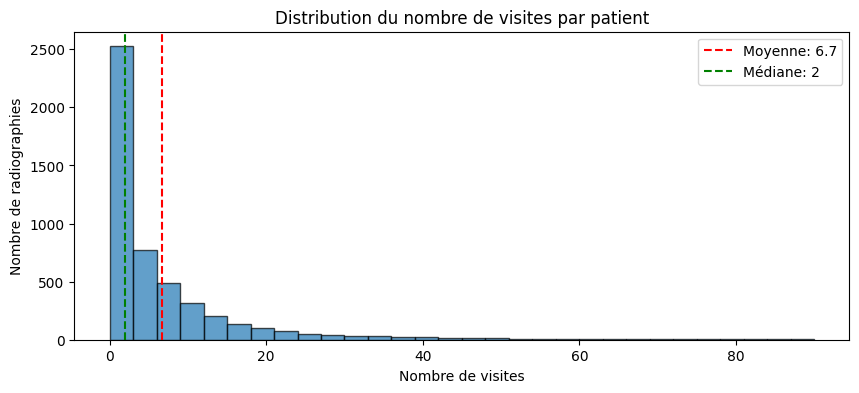

In [134]:
plt.figure(figsize=(10, 4))
plt.hist(df_clean['Follow-up #'], bins=30, edgecolor='black', alpha=0.7)
plt.axvline(df_clean['Follow-up #'].mean(), color='red', linestyle='--', label=f'Moyenne: {df_clean["Follow-up #"].mean():.1f}')
plt.axvline(df_clean['Follow-up #'].median(), color='green', linestyle='--', label=f'Médiane: {df_clean["Follow-up #"].median():.0f}')
plt.xlabel('Nombre de visites')
plt.ylabel('Nombre de radiographies')
plt.title('Distribution du nombre de visites par patient')
plt.legend()
plt.show()

In [135]:

visits_per_patient = df_clean.groupby('Patient ID').agg(
    n_visits       = ('Image Index', 'count'),
    gender         = ('Patient Gender', 'first'),
    age_group      = ('age_group', 'first'),
    view_position  = ('View Position', lambda x: x.mode()[0]),
    label          = ('label', lambda x: x.mode()[0])
).reset_index()


print("\n--- Visites moyennes par groupe ---")
print("Par genre :")
print(visits_per_patient.groupby('gender')['n_visits'].mean().round(2).to_string())
print("\nPar groupe d'âge :")
print(visits_per_patient.groupby('age_group', observed=True)['n_visits'].mean().round(2).to_string())
print("\nPar label (malade/sain) :")
print(visits_per_patient.groupby('label')['n_visits'].mean().round(2).to_string())




--- Visites moyennes par groupe ---
Par genre :
gender
F    2.97
M    3.62

Par groupe d'âge :
age_group
<40 ans      3.18
40-60 ans    3.14
>60 ans      3.87

Par label (malade/sain) :
label
malade    4.92
sain      2.41


# Pourquoi ce test est important ?

- Les patients avec beaucoup de visites contribuent à un grand nombre de radiographies.

- Si ces patients sont majoritairement d'un certain genre ou d'une certaine tranche d'âge,
  cela peut amplifier le**s biais** déjà identifiés.

- Le reweighting devra donc également compenser ce déséquilibre pour garantir
  que chaque patient contribue équitablement à l'entraînement du modèle,
  indépendamment de son nombre de visites.




---



# **Analyse des pathologies individuelles**

In [136]:
# Liste des pathologies à extraire (d'après la documentation NIH Chest X-ray)
pathology_list = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
    'Effusion', 'Emphysema', 'Fibrosis', 'Hernia',
    'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening',
    'Pneumonia', 'Pneumothorax'
]

for pathology in pathology_list:
    df_clean[pathology] = df_clean['Finding Labels'].str.contains(pathology, na=False).astype(int)


# ANALYSE DE LA PRÉVALENCE DES PATHOLOGIES
pathology_data = []
for patho in pathology_list:
    count = df_clean[patho].sum()
    pct = count / len(df_clean) * 100
    pathology_data.append({
        'pathologie': patho,
        'nombre_cas': count,
        'prevalence_pct': pct
    })
pathology_df = pd.DataFrame(pathology_data)
pathology_df = pathology_df.sort_values('nombre_cas', ascending=False).reset_index(drop=True)




Visualisation des top 10

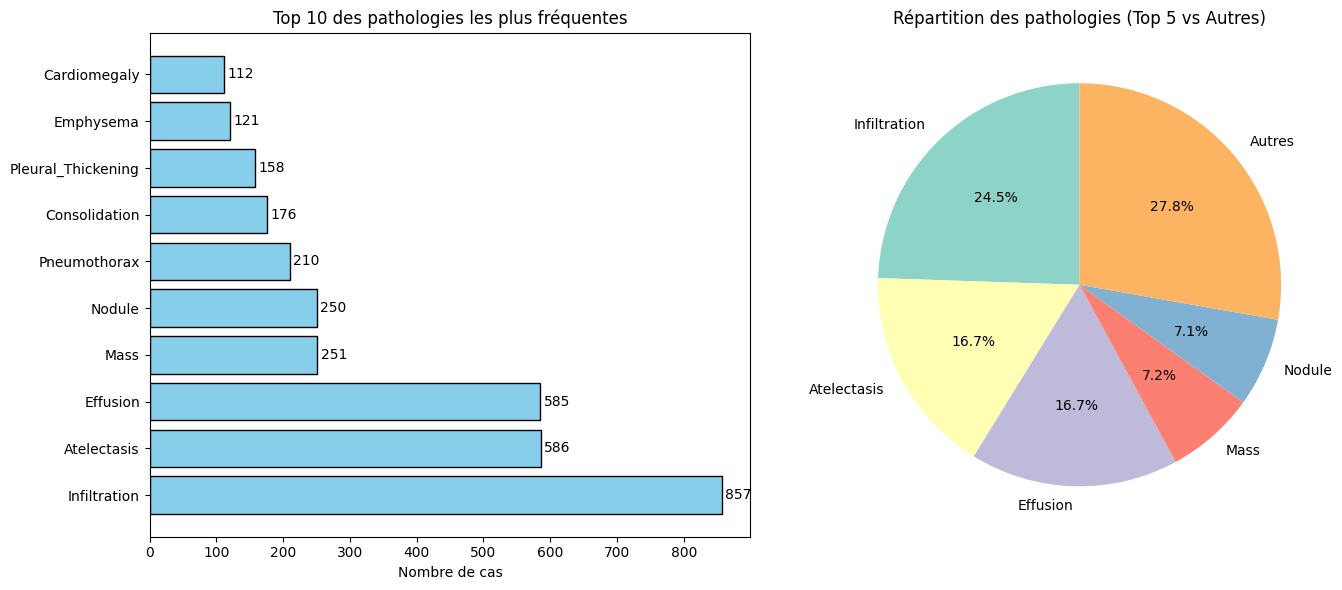

In [137]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_patho = pathology_df.head(10)
bars = axes[0].barh(range(len(top_patho)), top_patho['nombre_cas'].values,
                    color='skyblue', edgecolor='black')
axes[0].set_yticks(range(len(top_patho)))
axes[0].set_yticklabels(top_patho['pathologie'])
axes[0].set_xlabel('Nombre de cas')
axes[0].set_title('Top 10 des pathologies les plus fréquentes')

for i, bar in enumerate(bars):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{int(bar.get_width())}', va='center')

top5_count = top_patho.head(5)['nombre_cas'].sum()
other_count = pathology_df['nombre_cas'].sum() - top5_count
sizes = list(top_patho.head(5)['nombre_cas'].values) + [other_count]
labels = list(top_patho.head(5)['pathologie']) + ['Autres']
colors = plt.cm.Set3(range(len(sizes)))

axes[1].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Répartition des pathologies (Top 5 vs Autres)')

plt.tight_layout()
plt.show()


In [138]:
top1 = pathology_df.iloc[0]
print(f"\n**Pathologie la plus fréquente** : {top1['pathologie']}")
print(f"   → {top1['nombre_cas']} cas ({top1['prevalence_pct']:.1f}% du dataset)")

# Top 3
top3 = pathology_df.head(3)
print(f"\n**Top 3 des pathologies** :")
for _, row in top3.iterrows():
    print(f"   → {row['pathologie']}: {row['nombre_cas']} cas ({row['prevalence_pct']:.1f}%)")

# Statistiques sur les pathologies multiples
print("\n**Statistiques sur les comorbidités** :")
# Compter le nombre de pathologies par patient
df_clean['num_pathologies'] = df_clean[pathology_list].sum(axis=1)
print(f"   • Patients avec 0 pathologie : {(df_clean['num_pathologies'] == 0).sum()} ({((df_clean['num_pathologies'] == 0).sum()/len(df_clean)*100):.1f}%)")
print(f"   • Patients avec 1 pathologie : {(df_clean['num_pathologies'] == 1).sum()} ({((df_clean['num_pathologies'] == 1).sum()/len(df_clean)*100):.1f}%)")
print(f"   • Patients avec 2 pathologies ou plus : {(df_clean['num_pathologies'] >= 2).sum()} ({((df_clean['num_pathologies'] >= 2).sum()/len(df_clean)*100):.1f}%)")
print(f"   • Nombre moyen de pathologies par patient : {df_clean['num_pathologies'].mean():.2f}")




**Pathologie la plus fréquente** : Infiltration
   → 857 cas (17.3% du dataset)

**Top 3 des pathologies** :
   → Infiltration: 857 cas (17.3%)
   → Atelectasis: 586 cas (11.8%)
   → Effusion: 585 cas (11.8%)

**Statistiques sur les comorbidités** :
   • Patients avec 0 pathologie : 2715 (54.8%)
   • Patients avec 1 pathologie : 1360 (27.5%)
   • Patients avec 2 pathologies ou plus : 876 (17.7%)
   • Nombre moyen de pathologies par patient : 0.71


# Interpretation


**1. Distribution des pathologies**
- La pathologie la plus fréquente est **Infiltration** avec 857 cas (17.3% du dataset).
- Les 3 pathologies les plus fréquentes sont : **Infiltration**, **Atelectasis**, **Effusion**.

→ **Pourquoi c'est important** : Le modèle sera naturellement meilleur pour détecter
  ces pathologies fréquentes qui représentent déjà 40.9% de tous les cas de pathologies.
  Il faudra être particulièrement vigilant sur les pathologies rares comme Hernia,
  Fibrosis ou Pneumonia qui risquent d'être sous-détectées faute de données suffisantes.

**2. Comorbidités (patients avec plusieurs pathologies)**
- **54.8%** des patients n'ont aucune pathologie (sains)
- **27.5%** des patients ont une seule pathologie
- **17.7%** des patients ont 2 pathologies ou plus
- Nombre moyen de pathologies par patient : **0.71**

→ **Pourquoi c'est important** : Près d'un patient sur cinq (17.7%) présente des
  comorbidités (au moins 2 pathologies). Ces cas complexes sont cliniquement
  importants mais aussi plus difficiles à diagnostiquer. Si ces patients
  multimorbides sont sur-représentés dans certains groupes démographiques
  (ex: personnes âgées, hommes), cela peut amplifier les biais existants.

**3. Implications pour l'équité (fairness)**
- Les pathologies fréquentes comme **Infiltration** (17.3%) et **Atelectasis** (11.8%)
  pourraient dominer l'entraînement du modèle au détriment des pathologies rares.
- Si ces pathologies sont plus présentes chez un genre ou une tranche d'âge spécifique,
  le modèle risque d'apprendre à associer ces groupes démographiques à la maladie,
  créant ainsi un biais injustifié.




---



# **Analyse des corrélations entre variables**

In [139]:
corr_matrix = df_clean[['gender_bin', 'Patient Age', 'view_bin', 'label_bin']].corr()


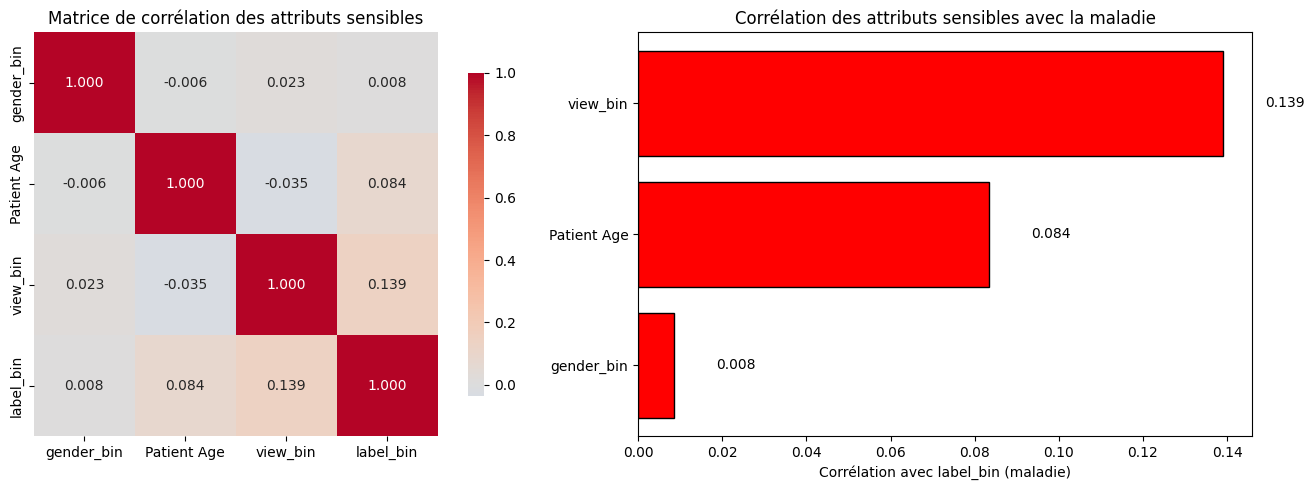

In [140]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f',
            square=True, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Matrice de corrélation des attributs sensibles')

corr_with_label = corr_matrix['label_bin'].drop('label_bin').sort_values()
colors = ['salmon' if x < 0 else 'red' for x in corr_with_label.values]
bars = axes[1].barh(corr_with_label.index, corr_with_label.values, color=colors, edgecolor='black')
axes[1].set_xlabel('Corrélation avec label_bin (maladie)')
axes[1].set_title('Corrélation des attributs sensibles avec la maladie')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

for bar in bars:
    width = bar.get_width()
    axes[1].text(width + 0.01 if width > 0 else width - 0.05,
                 bar.get_y() + bar.get_height()/2,
                 f'{width:.3f}', va='center')

plt.tight_layout()
plt.show()

**INTERPRETATION**


> Corrélation avec la maladie (label_bin):

La position de vue (view_bin) présente la corrélation la plus élevée avec la maladie, avec un coefficient de 0,139. Bien que cette valeur reste faible en valeur absolue, elle est significativement plus élevée que les autres. Cela confirme notre détection antérieure : les patients filmés en position AP sont plus souvent malades que ceux filmés en PA.





*  L'âge (Patient Age)

 affiche une corrélation de 0,084 avec la maladie. Cette corrélation positive, bien que modeste, reflète une réalité médicale : les personnes âgées présentent effectivement un risque plus élevé de pathologies pulmonaires. Cependant, cette tendance doit être surveillée pour éviter que le modèle n'apprenne à diagnostiquer l'âge plutôt que les véritables signes radiologiques.

* Le genre (gender_bin)

présente une corrélation quasi nulle de 0,008 avec la maladie. Cela indique qu'il n'existe pas de relation linéaire directe entre le genre et le statut de maladie dans notre dataset. Les différences observées précédemment dans l'analyse bivariée sont donc très faibles et pourraient être dues au hasard.





> Corrélations entre attributs sensibles :


montre des valeurs extrêmement faibles, proches de zéro. La corrélation entre l'âge et la position de vue est de -0,035, celle entre le genre et l'âge de -0,006, et celle entre le genre et la position de vue de 0,023. Ces résultats indiquent que les trois attributs sensibles sont indépendants les uns des autres.

Cette indépendance est une bonne nouvelle car elle signifie que les biais potentiels sont séparés et peuvent être corrigés indépendamment sans risque d'interférence.


# SYNTHESE:


*  L'analyse des corrélations confirme nos observations antérieures :



le biais principal provient de la **position de vue,** qui sera donc notre priorité absolue dans les méthodes de mitigation.

L'âge présente un biais modéré mais cohérent avec la réalité médicale, justifiant une correction secondaire.

Le genre, en revanche, n'a pratiquement aucun impact direct sur le statut de maladie, ce qui relativise l'importance de sa correction.


**Ces résultats** nous guident dans le choix des stratégies de reweighting : nous commencerons par corriger la position de vue, puis intégrerons progressivement l'âge et éventuellement le genre pour obtenir un dataset parfaitement équilibré.



---





---





---



# **ANALYSE BIVARIÉE - TAUX DE MALADIE PAR GROUPE**



---



Analyse bivariée - Taux de maladie par groupe


>C'est ici que nous détectons les biais potentiels. Nous calculons le taux de maladie
pour chaque groupe d'attribut sensible. Si ces taux diffèrent significativement,
cela indique un biais dans les données.



Taux de maladie par genre

In [141]:
disease_by_gender = df_clean.groupby('gender_bin')['label_bin'].mean()
print(f"  Femmes (0): {disease_by_gender[0]:.3f} ({disease_by_gender[0]*100:.1f}%)")
print(f"  Hommes (1) : {disease_by_gender[1]:.3f} ({disease_by_gender[1]*100:.1f}%)")
print(f"  Écart absolu : {abs(disease_by_gender[1] - disease_by_gender[0]):.3f}")

  Femmes (0): 0.447 (44.7%)
  Hommes (1) : 0.455 (45.5%)
  Écart absolu : 0.008


Taux de maladie par groupe d'âge

In [142]:
disease_by_age = df_clean.groupby('age_group')['label_bin'].mean().sort_index()
for group, rate in disease_by_age.items():
    print(f"  {group}: {rate:.3f} ({rate*100:.1f}%)")

print(f"  Écart entre <40 ans et >60 ans : {disease_by_age['>60 ans'] - disease_by_age['<40 ans']:.3f}")

  <40 ans: 0.410 (41.0%)
  40-60 ans: 0.446 (44.6%)
  >60 ans: 0.521 (52.1%)
  Écart entre <40 ans et >60 ans : 0.111


Taux de maladie par position de vue

In [143]:
disease_by_view = df_clean.groupby('view_bin')['label_bin'].mean()
print(f"  PA (0): {disease_by_view[0]:.3f} ({disease_by_view[0]*100:.1f}%)")
print(f"  AP (1) : {disease_by_view[1]:.3f} ({disease_by_view[1]*100:.1f}%)")
print(f"  Écart absolu : {abs(disease_by_view[1] - disease_by_view[0]):.3f}")

  PA (0): 0.400 (40.0%)
  AP (1) : 0.544 (54.4%)
  Écart absolu : 0.144


**Visualisation des taux**

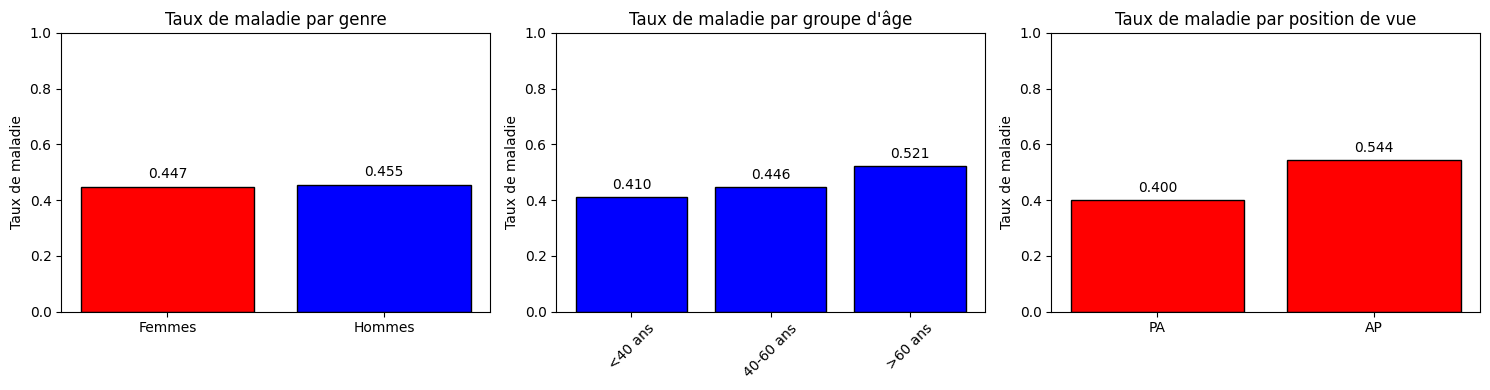

In [144]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Genre
bars1 = axes[0].bar(['Femmes', 'Hommes'], disease_by_gender.values,
                    color=['red', 'blue'], edgecolor='black')
axes[0].set_ylabel('Taux de maladie')
axes[0].set_title('Taux de maladie par genre')
axes[0].set_ylim(0, 1)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                 f'{bar.get_height():.3f}', ha='center', va='bottom')

# Âge
bars2 = axes[1].bar(disease_by_age.index, disease_by_age.values,
                    color='blue', edgecolor='black')
axes[1].set_ylabel('Taux de maladie')
axes[1].set_title('Taux de maladie par groupe d\'âge')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0, 1)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                 f'{bar.get_height():.3f}', ha='center', va='bottom')

# Position de vue
bars3 = axes[2].bar(['PA', 'AP'], disease_by_view.values,
                    color='red', edgecolor='black')
axes[2].set_ylabel('Taux de maladie')
axes[2].set_title('Taux de maladie par position de vue')
axes[2].set_ylim(0, 1)
for bar in bars3:
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                 f'{bar.get_height():.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# **INTERPRETATION DES RESULTATS**

- **Genre** :

 Les hommes présentent un taux de maladie légèrement plus élevé que les femmes (45,5% contre 44,7%), soit un écart de seulement 0,8 point. Cette différence est très faible et, comme nous l'avons vu dans l'analyse des corrélations (corrélation de 0,008), elle n'est pas significative. Le genre n'a donc pratiquement aucun impact sur le statut de maladie dans notre dataset. La correction du biais de genre sera donc une priorité faible dans nos méthodes de mitigation.

- **Âge** :

On observe une tendance claire et progressive : plus les patients sont âgés, plus le taux de maladie est élevé. Les moins de 40 ans ont un taux de 41,0%, les 40-60 ans 44,6%, et les plus de 60 ans atteignent 52,1%. L'écart de 11,1 points entre les plus jeunes et les plus âgés est significatif.

Cette tendance reflète une réalité médicale : les personnes âgées sont effectivement plus susceptibles de développer des pathologies pulmonaires. Cependant, elle peut poser un problème d'équité si le modèle apprend à associer l'âge à la maladie plutôt que les véritables signes radiologiques. La correction du biais lié à l'âge sera une priorité modérée.

- **Position de vue** :

C'est le résultat le plus frappant de cette analyse. Les patients filmés en position AP (antéro-postérieure) sont beaucoup plus souvent malades (54,4%) que ceux filmés en PA (postéro-antérieure) avec seulement 40,0% de malades. L'écart de 14,4 points est considérable.

Cette différence peut s'expliquer par des raisons cliniques : les patients alités ou en état grave sont plus souvent filmés en AP car cette position est plus accessible lorsqu'ils ne peuvent pas se tenir debout. Cela crée un biais technique majeur : la position de vue est corrélée à la gravité de l'état du patient. Si le modèle apprend cette corrélation, il risque de diagnostiquer une maladie simplement parce que l'image a été prise en AP, sans se baser sur les véritables signes radiologiques.

La correction du biais lié à la position de vue sera notre priorité absolue dans les méthodes de mitigation.


---



**Conclusion de l'analyse bivariée**


---

L'analyse bivariée confirme et quantifie les biais pressentis dans l'analyse univariée :

Le biais de genre est négligeable : l'écart de seulement 0,8 point et la corrélation quasi nulle (0,008) indiquent que le genre n'influence pas significativement le statut de maladie.

Le biais lié à l'âge est modéré mais réel : la progression régulière du taux de maladie avec l'âge (de 41% à 52%) reflète une réalité clinique. Une correction est souhaitable pour éviter que le modèle n'apprenne à "diagnostiquer" l'âge.

Le biais lié à la position de vue est majeur : avec un écart de 14,4 points, c'est le biais le plus important à corriger. Les patients filmés en AP sont beaucoup plus souvent malades, créant une corrélation artificielle que le modèle pourrait exploiter.





---





---



# ANALYSE BIVARIÉE ENTRE ATTRIBUTS SENSIBLES

# **TESTS STATISTIQUES - SIGNIFICATIVITÉ DES BIAIS**




---




> Pour confirmer que les différences observées ne sont pas dues au hasard,
nous effectuons des tests statistiques :
- **Chi-2** pour les variables catégorielles (genre, position de vue)
- **Test t de Student** pour comparer l'âge moyen entre malades et sains





In [145]:
from scipy import stats


# Test Chi-2 pour le genre

In [146]:
contingency_gender = pd.crosstab(df_clean['gender_bin'], df_clean['label_bin'])
chi2_gender, p_gender, dof_gender, expected_gender = stats.chi2_contingency(contingency_gender)
print(f"  Chi-2 = {chi2_gender:.4f}")
print(f"  p-value = {p_gender:.6f}")
print()
if p_gender < 0.05:
    print("  → Résultat : Association SIGNIFICATIVE entre genre et maladie (p < 0.05)")
    print("     → Le biais de genre est confirmé statistiquement.")
else:
    print("  → Résultat : Pas d'association significative (p > 0.05)")
    print("  → Les différences observées pourraient être dues au hasard.")

  Chi-2 = 0.3210
  p-value = 0.570992

  → Résultat : Pas d'association significative (p > 0.05)
  → Les différences observées pourraient être dues au hasard.


#Test Chi-2 pour la position de vue

In [147]:
contingency_view = pd.crosstab(df_clean['view_bin'], df_clean['label_bin'])
chi2_view, p_view, dof_view, expected_view = stats.chi2_contingency(contingency_view)
print(f"  Chi-2 = {chi2_view:.4f}")
print(f"  p-value = {p_view:.6f}")
print()
if p_view < 0.05:
    print("  → Résultat : Association TRÈS SIGNIFICATIVE entre position de vue et maladie (p < 0.001)")
    print("  → Le biais technique lié à la position de vue est avéré et majeur.")

  Chi-2 = 95.0649
  p-value = 0.000000

  → Résultat : Association TRÈS SIGNIFICATIVE entre position de vue et maladie (p < 0.001)
  → Le biais technique lié à la position de vue est avéré et majeur.


#Test t pour l'âge (comparaison malades vs sains)

In [148]:
age_malades = df_clean[df_clean['label_bin'] == 1]['Patient Age']
age_sains = df_clean[df_clean['label_bin'] == 0]['Patient Age']
t_stat, p_age = stats.ttest_ind(age_malades, age_sains)
print(f"  Âge moyen - Malades: {age_malades.mean():.1f} ans")
print(f"  Âge moyen - Sains: {age_sains.mean():.1f} ans")
print(f"  Écart : {age_malades.mean() - age_sains.mean():.1f} ans")
print(f"  t-stat = {t_stat:.4f}, p-value = {p_age:.6f}")
print()
if p_age < 0.05:
    print("  → Résultat : Différence d'âge SIGNIFICATIVE entre malades et sains (p < 0.001)")
    print("  → Les patients malades sont en moyenne plus âgés.")
else:
    print("  → Résultat : Pas de différence significative (p > 0.05)")

  Âge moyen - Malades: 48.5 ans
  Âge moyen - Sains: 45.7 ans
  Écart : 2.8 ans
  t-stat = 5.8961, p-value = 0.000000

  → Résultat : Différence d'âge SIGNIFICATIVE entre malades et sains (p < 0.001)
  → Les patients malades sont en moyenne plus âgés.


# SYNTHÈSE DES BIAIS IDENTIFIÉS

In [149]:
biais_df = pd.DataFrame({
    'Attribut': ['Genre', 'Âge', 'Position de vue'],
    'Taux groupe 1': ['44.7% (Femmes)', '41.0% (<40 ans)', '40.0% (PA)'],
    'Taux groupe 2': ['45.5% (Hommes)', '52.1% (>60 ans)', '54.4% (AP)'],
    'Écart': ['0.8 pt', '11.1 pts', '14.4 pts'],
    'Priorité': ['Faible', 'Modérée', 'ÉLEVÉE']
})
print(biais_df.to_string(index=False))

       Attribut   Taux groupe 1   Taux groupe 2    Écart Priorité
          Genre  44.7% (Femmes)  45.5% (Hommes)   0.8 pt   Faible
            Âge 41.0% (<40 ans) 52.1% (>60 ans) 11.1 pts  Modérée
Position de vue      40.0% (PA)      54.4% (AP) 14.4 pts   ÉLEVÉE




---





L'analyse bivariée a permis d'identifier et de quantifier trois types de biais :

1. **Biais de genre** : écart de 0,8 point → négligeable
2. **Biais d'âge** : écart de 11,1 points → modéré, reflète une réalité médicale
3. **Biais de position de vue** : écart de 14,4 points → MAJEUR

Ces résultats nous guident pour la suite. Nous allons maintenant appliquer des méthodes de **pré-processing (reweighting)** pour corriger ces biais, en priorité la position de vue, puis l'âge, et enfin le genre si nécessaire.






# > **L'objectif est d'obtenir un dataset équilibré où les attributs sensibles n'influencent plus la prédiction de la maladie.**





---



# Métriques de fairness (DPD et DI):



Avant d'appliquer des méthodes de correction, il est essentiel de quantifier objectivement les biais identifiés. Nous utilisons deux métriques standardisées :

- **DPD** : différence absolue des taux de maladie entre groupes (idéal < 0,05)
- **DI** : rapport des taux entre groupes défavorisé et favorisé (idéal entre 0,8 et 1,2)



> Ces valeurs serviront de référence pour évaluer l'impact des corrections.



Nous calculons ces indicateurs pour les trois attributs sensibles : le genre, l'âge (groupes extrêmes) et la position de vue.








---



In [150]:
def calculate_fairness_metrics(dataframe, sensitive_attr, target, attr_names=None):
    """Calcule DPD et DI pour un attribut sensible donné"""
    groups = dataframe[sensitive_attr].unique()
    rates = {}
    for group in groups:
        rates[group] = dataframe[dataframe[sensitive_attr] == group][target].mean()

    if len(groups) == 2:
        g1, g2 = groups
        dpd = abs(rates[g1] - rates[g2])
        di = min(rates[g1], rates[g2]) / max(rates[g1], rates[g2])
        return {'dpd': dpd, 'di': di, 'rates': rates}
    return None

# Métriques pour le genre

In [151]:
gender_metrics = calculate_fairness_metrics(df_clean, 'gender_bin', 'label_bin')
print(f"  Taux Hommes (1): {gender_metrics['rates'][1]:.3f}")
print(f"  Taux Femmes (0): {gender_metrics['rates'][0]:.3f}")
print(f"  DPD (Demographic Parity Difference): {gender_metrics['dpd']:.4f}")
print(f"  DI (Disparate Impact): {gender_metrics['di']:.4f}")
if gender_metrics['di'] < 0.8 or gender_metrics['di'] > 1.2:
    print("  → Attention : DI hors des limites usuelles (0.8-1.2)")

  Taux Hommes (1): 0.455
  Taux Femmes (0): 0.447
  DPD (Demographic Parity Difference): 0.0085
  DI (Disparate Impact): 0.9814


# Métriques pour la position de vue

In [152]:
view_metrics = calculate_fairness_metrics(df_clean, 'view_bin', 'label_bin')
print(f"  Taux AP (1): {view_metrics['rates'][1]:.3f}")
print(f"  Taux PA (0): {view_metrics['rates'][0]:.3f}")
print(f"  DPD: {view_metrics['dpd']:.4f}")
print(f"  DI: {view_metrics['di']:.4f}")
if view_metrics['di'] < 0.8:
    print("  → BIAIS MAJEUR : DI < 0.8, correction indispensable !")

  Taux AP (1): 0.544
  Taux PA (0): 0.400
  DPD: 0.1440
  DI: 0.7351
  → BIAIS MAJEUR : DI < 0.8, correction indispensable !


# Métriques pour l'âge (groupes extrêmes)

In [153]:
age_rates = df_clean.groupby('age_group')['label_bin'].mean()
print(f"  <40 ans: {age_rates['<40 ans']:.3f}")
print(f"  40-60 ans: {age_rates['40-60 ans']:.3f}")
print(f"  >60 ans: {age_rates['>60 ans']:.3f}")
dpd_age = age_rates.max() - age_rates.min()
di_age = age_rates.min() / age_rates.max()
print()
print(f"  DPD (entre <40 et >60): {dpd_age:.4f}")
print(f"  DI (entre <40 et >60): {di_age:.4f}")

  <40 ans: 0.410
  40-60 ans: 0.446
  >60 ans: 0.521

  DPD (entre <40 et >60): 0.1107
  DI (entre <40 et >60): 0.7876


In [154]:
print("\nTABLEAU RÉCAPITULATIF DES MÉTRIQUES AVANT CORRECTION")
print("="*70)

metrics_before = pd.DataFrame({
    'Attribut': ['Genre', 'Âge', 'Position de vue'],
    'Taux groupe 1': [f"{gender_metrics['rates'][1]*100:.1f}%", f"{age_rates['<40 ans']*100:.1f}%", f"{view_metrics['rates'][1]*100:.1f}%"],
    'Taux groupe 2': [f"{gender_metrics['rates'][0]*100:.1f}%", f"{age_rates['>60 ans']*100:.1f}%", f"{view_metrics['rates'][0]*100:.1f}%"],
    'DPD': [f"{gender_metrics['dpd']:.4f}", f"{dpd_age:.4f}", f"{view_metrics['dpd']:.4f}"],
    'DI': [f"{gender_metrics['di']:.4f}", f"{di_age:.4f}", f"{view_metrics['di']:.4f}"],
    'Statut': [
        'OK' if gender_metrics['di'] > 0.8 else 'À corriger',
        'À surveiller' if di_age < 0.8 else 'OK',
        'À CORRIGER' if view_metrics['di'] < 0.8 else 'OK'
    ]
})
print(metrics_before.to_string(index=False))




TABLEAU RÉCAPITULATIF DES MÉTRIQUES AVANT CORRECTION
       Attribut Taux groupe 1 Taux groupe 2    DPD     DI       Statut
          Genre         45.5%         44.7% 0.0085 0.9814           OK
            Âge         41.0%         52.1% 0.1107 0.7876 À surveiller
Position de vue         54.4%         40.0% 0.1440 0.7351   À CORRIGER


# **Métriques calculées. Passons maintenant au reweighting**



---



#  Méthodes de Pré-processing pour Réduire les Biais - méthode de mitigation des biais par pré-processing

# Méthode : Reweighing (Re-pondération)Reweighting

Methode du Reweighting ou au lieu de changer le nombre de personnes, on change leur "importance" c'est a dire leur poids dans mon dataset !
Comme ça, le modèle va "voir" autant d'hommes malades que de femmes malades, sans supprimer personne !

## Pre-processing : impact de la pondération

### Principe
Le modèle ResNet18 prend uniquement les images en entrée, sans les métadonnées.
Cependant, il peut retrouver des attributs comme le genre, l'âge ou la position de vue à partir des images seules, ce qui peut amplifier les biais présents dans
les données.

Pour corriger cela, on modifie la colonne `WEIGHTS` du CSV afin de donner plus ou moins d'importance à certains groupes pendant l'entraînement.



In [155]:
weights = np.ones(len(df_clean))
n_total = len(df_clean)

In [156]:
def compute_reweighing_weights(df, sensitive_attr, label_col):
    weights = np.ones(len(df))
    n_total = len(df)
#on parcourt les valeurs possible de l'attribut sensible et otutes les valeurs possibles du label
    for s_val in df[sensitive_attr].unique():
        for y_val in df[label_col].unique():
        #on veut uniquement conserver les lignes qui correspondent à cette combinaison
            select = (df[sensitive_attr] == s_val) & (df[label_col] == y_val)
            p_sy = select.sum() / n_total
            p_s  = (df[sensitive_attr] == s_val).sum() / n_total  #
            p_y  = (df[label_col] == y_val).sum() / n_total
            if p_sy > 0:
              #reweighting sous-représenté, poids>1 et sur-représenté, le poids < 1
                w_val = (p_s * p_y) / p_sy
                # Assigner le poids aux lignes correspondantes
                loc_idx = np.where(select.values)[0]
                weights[loc_idx] = w_val
    return weights


### Et sur nos données ?

### Stratégies testées
1. Baseline : tous les poids = 1 (aucune correction)
2. Reweighting par label : corriger le déséquilibre malade/sain
3. Reweighting par label + genre : corriger malade/sain ET homme/femme
4. Reweighting par label + genre + âge : corriger les 3 à la fois

### On travaille uniquement sur le split train pour le reweighting

In [157]:
# On travaille uniquement sur le split train
df_train = df_clean[df_clean['train_valid'] == 'train'].copy()

### Stratégie 1 : Baseline (poids = 1)

In [158]:
df_clean['WEIGHTS_baseline'] = 1.0

### Stratégie 2 : Reweighting par label

In [159]:
df_clean['WEIGHTS_label'] = 1.0
w = compute_reweighing_weights(df_train, 'label_bin', 'label_bin')
df_clean.loc[df_clean['train_valid'] == 'train', 'WEIGHTS_label'] = w

### Stratégie 3 : Reweighting par label + genre

In [160]:
# Stratégie 3 : Reweighting par label + genre
# On crée une colonne combinée label_genre
df_train['label_genre'] = df_train['label_bin'].astype(str) + '_' + df_train['gender_bin'].astype(str)
df_clean['label_genre'] = df_clean['label_bin'].astype(str) + '_' + df_clean['gender_bin'].astype(str)
w_label_genre = compute_reweighing_weights(df_train, 'label_genre', 'label_bin')
df_clean['WEIGHTS_label_genre'] = 1.0
df_clean.loc[df_clean['train_valid'] == 'train', 'WEIGHTS_label_genre'] = w_label_genre


### Stratégie 4 : Reweighting par label + genre + âge

In [161]:
df_train['label_genre_age'] = df_train['label_bin'].astype(str) + '_' + df_train['gender_bin'].astype(str) + '_' + df_train['age_group'].astype(str)
df_clean['label_genre_age'] = df_clean['label_bin'].astype(str) + '_' + df_clean['gender_bin'].astype(str) + '_' + df_clean['age_group'].astype(str)
w_label_genre_age = compute_reweighing_weights(df_train, 'label_genre_age', 'label_bin')
df_clean['WEIGHTS_label_genre_age'] = 1.0
df_clean.loc[df_clean['train_valid'] == 'train', 'WEIGHTS_label_genre_age'] = w_label_genre_age

### Stratégie 5 : Reweighting par label + view position

In [162]:
df_train['label_view'] = df_train['label_bin'].astype(str) + '_' + df_train['view_bin'].astype(str)
df_clean['label_view'] = df_clean['label_bin'].astype(str) + '_' + df_clean['view_bin'].astype(str)
w_label_view = compute_reweighing_weights(df_train, 'label_view', 'label_bin')
df_clean['WEIGHTS_label_view'] = 1.0
df_clean.loc[df_clean['train_valid'] == 'train', 'WEIGHTS_label_view'] = w_label_view

# Stratégie 6 : Reweighting par label + view + age

In [163]:
df_train['label_view_age'] = (
    df_train['label_bin'].astype(str) + '_' +
    df_train['view_bin'].astype(str) + '_' +
    df_train['age_group'].astype(str)
)

df_clean['label_view_age'] = (
    df_clean['label_bin'].astype(str) + '_' +
    df_clean['view_bin'].astype(str) + '_' +
    df_clean['age_group'].astype(str)
)


w_label_view_age = compute_reweighing_weights(df_train, 'label_view_age', 'label_bin')
df_clean['WEIGHTS_label_view_age'] = 1.0
df_clean.loc[df_clean['train_valid'] == 'train', 'WEIGHTS_label_view_age'] = w_label_view_age

In [164]:
print(df_clean[['WEIGHTS_baseline','WEIGHTS_label',
                'WEIGHTS_label_genre','WEIGHTS_label_genre_age','WEIGHTS_label_view','WEIGHTS_label_view_age']].describe().round(3))

       WEIGHTS_baseline  WEIGHTS_label  WEIGHTS_label_genre  \
count            4951.0       4951.000             4951.000   
mean                1.0          0.620                0.620   
std                 0.0          0.214                0.214   
min                 1.0          0.452                0.452   
25%                 1.0          0.452                0.452   
50%                 1.0          0.548                0.548   
75%                 1.0          0.548                0.548   
max                 1.0          1.000                1.000   

       WEIGHTS_label_genre_age  WEIGHTS_label_view  WEIGHTS_label_view_age  
count                 4951.000            4951.000                4951.000  
mean                     0.620               0.620                   0.620  
std                      0.214               0.214                   0.214  
min                      0.452               0.452                   0.452  
25%                      0.452               0.

# TABLEAU RÉCAPITULATIF DES STRATÉGIES DE REWEIGHTING


In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("TABLEAU RÉCAPITULATIF DES STRATÉGIES DE REWEIGHTING")
print("="*80)

# Liste de vos stratégies
strategies = [
    {
        'Stratégie': 'Baseline',
        'Colonne': 'WEIGHTS_baseline',
        'Description': 'Poids uniformes (1.0) - Référence',
        'Biais corrigés': 'Aucun',
        'Type': 'Référence'
    },
    {
        'Stratégie': 'Label',
        'Colonne': 'WEIGHTS_label',
        'Description': 'Correction du déséquilibre malade/sain',
        'Biais corrigés': 'Déséquilibre classes (45.2% malades vs 54.8% sains)',
        'Type': 'Class balancing'
    },
    {
        'Stratégie': 'Label + Genre',
        'Colonne': 'WEIGHTS_label_genre',
        'Description': 'Correction malade/sain + genre',
        'Biais corrigés': 'Déséquilibre classes + Genre',
        'Type': 'Multi-attribut'
    },
    {
        'Stratégie': 'Label + Genre + Âge',
        'Colonne': 'WEIGHTS_label_genre_age',
        'Description': 'Correction malade/sain + genre + âge',
        'Biais corrigés': 'Déséquilibre classes + Genre + Âge',
        'Type': 'Multi-attribut'
    },
    {
        'Stratégie': 'Label + View ',
        'Colonne': 'WEIGHTS_label_view',
        'Description': 'Correction malade/sain + position de vue (PRIORITÉ)',
        'Biais corrigés': 'Déséquilibre classes + Position vue (biais MAJEUR)',
        'Type': 'Multi-attribut prioritaire'
    },
    {
        'Stratégie': 'Label + View + Âge',
        'Colonne': 'WEIGHTS_label_view_age',
        'Description': 'Correction complète: classes + view + âge',
        'Biais corrigés': 'Déséquilibre classes + Position vue + Âge',
        'Type': 'Multi-attribut complet'
    }
]

# Calculer les statistiques pour chaque stratégie
stats_list = []
for s in strategies:
    col = s['Colonne']
    train_weights = df_clean[df_clean['train_valid'] == 'train'][col]
    stats_list.append({
        'Stratégie': s['Stratégie'],
        'Colonne': col,
        'Description': s['Description'],
        'Biais corrigés': s['Biais corrigés'],
        'Type': s['Type'],
        'Min': train_weights.min(),
        'Max': train_weights.max(),
        'Moyenne': train_weights.mean(),
        'Écart-type': train_weights.std(),
        'Ratio max/min': train_weights.max() / train_weights.min()
    })

df_strategies = pd.DataFrame(stats_list)

# Afficher le tableau principal
print("\n TABLEAU 1: DESCRIPTION DES STRATÉGIES")
print("-"*80)
display_cols = ['Stratégie', 'Description', 'Biais corrigés', 'Type']
print(df_strategies[display_cols].to_string(index=False))

print("\n TABLEAU 2: STATISTIQUES DES POIDS (sur le TRAIN uniquement)")
print("-"*80)
print(df_strategies[['Stratégie', 'Min', 'Max', 'Moyenne', 'Écart-type', 'Ratio max/min']].round(4).to_string(index=False))

TABLEAU RÉCAPITULATIF DES STRATÉGIES DE REWEIGHTING

 TABLEAU 1: DESCRIPTION DES STRATÉGIES
--------------------------------------------------------------------------------
          Stratégie                                         Description                                      Biais corrigés                       Type
           Baseline                   Poids uniformes (1.0) - Référence                                               Aucun                  Référence
              Label              Correction du déséquilibre malade/sain Déséquilibre classes (45.2% malades vs 54.8% sains)            Class balancing
      Label + Genre                      Correction malade/sain + genre                        Déséquilibre classes + Genre             Multi-attribut
Label + Genre + Âge                Correction malade/sain + genre + âge                  Déséquilibre classes + Genre + Âge             Multi-attribut
      Label + View  Correction malade/sain + position de vue (PRIORITÉ) 

# **INTERPRÉTATION DÉTAILLÉE DES STRATÉGIES**

In [166]:


print("\n" + "="*80)
print(" INTERPRÉTATION DES STRATÉGIES DE REWEIGHTING")
print("="*80)

print("\n┌────────────────────────────────────────────────────────────────────────────────────────────────────┐")
print("│  STRATÉGIE       │  RATIO  │  INTERPRÉTATION                                 ")
print("├────────────────────────────────────────────────────────────────────────────────────────────────────┤")

for _, row in df_strategies.iterrows():
    ratio = row['Ratio max/min']
    strategie = row['Stratégie'].ljust(16)

    if row['Stratégie'] == 'Baseline':
        print(f"│  {strategie}│  {ratio:.3f}   │  ✅ Poids uniformes — référence pour comparaison                    ")
    elif ratio < 1.1:
        print(f"│  {strategie}│  {ratio:.3f}   │  ✅ Correction légère — groupes déjà bien équilibrés          ")
    elif ratio < 1.3:
        print(f"│  {strategie}│  {ratio:.3f}   │  ⚠️  Correction modérée — impact significatif sur l'entraînement")
    else:
        print(f"│  {strategie}│  {ratio:.3f}   │  ❌ Correction forte — risque de surapprentissage             ")

print("└────────────────────────────────────────────────────────────────────────────────────────────────────┘")


 INTERPRÉTATION DES STRATÉGIES DE REWEIGHTING

┌────────────────────────────────────────────────────────────────────────────────────────────────────┐
│  STRATÉGIE       │  RATIO  │  INTERPRÉTATION                                 
├────────────────────────────────────────────────────────────────────────────────────────────────────┤
│  Baseline        │  1.000   │  ✅ Poids uniformes — référence pour comparaison                    
│  Label           │  1.213   │  ⚠️  Correction modérée — impact significatif sur l'entraînement
│  Label + Genre   │  1.213   │  ⚠️  Correction modérée — impact significatif sur l'entraînement
│  Label + Genre + Âge│  1.213   │  ⚠️  Correction modérée — impact significatif sur l'entraînement
│  Label + View    │  1.213   │  ⚠️  Correction modérée — impact significatif sur l'entraînement
│  Label + View + Âge│  1.213   │  ⚠️  Correction modérée — impact significatif sur l'entraînement
└───────────────────────────────────────────────────────────────────────────

# ANALYSE DE L'EFFICACITÉ DES STRATÉGIES

In [167]:
# Analyser chaque stratégie
for _, row in df_strategies.iterrows():
    print(f"\n📌 {row['Stratégie']}:")
    print(f"   Description: {row['Description']}")
    print(f"   Statistiques: min={row['Min']:.3f}, max={row['Max']:.3f}, ratio={row['Ratio max/min']:.3f}")

    # Interprétation spécifique
    if row['Stratégie'] == 'Baseline':
        print(f"    Rôle: Stratégie de référence pour évaluer l'impact des corrections")

    elif row['Stratégie'] == 'Label':
        print(f"    Objectif: Équilibrer les classes malade (45.2%) et sain (54.8%)")
        print(f"    Poids < 1: Groupe sur-représenté (sains) → moins d'importance")
        print(f"    Poids > 1: Groupe sous-représenté (malades) → plus d'importance")

    elif row['Stratégie'] == 'Label + View ':
        print(f"    Objectif: Corriger le biais MAJEUR de la position de vue")
        print(f"    Contexte: 40.0% malades en PA vs 54.4% malades en AP (écart 14.4 pts)")
        print(f"    PRIORITÉ ABSOLUE: Cette stratégie cible le biais le plus important")

    elif 'Genre' in row['Stratégie']:
        print(f"    Objectif: Réduire le biais de genre (écart de 0.8 point seulement)")
        print(f"    Note: Le biais de genre est déjà très faible dans les données")

    elif 'Âge' in row['Stratégie'] or 'age' in row['Stratégie'].lower():
        print(f"    Objectif: Corriger le biais d'âge (41.0% vs 52.1%, écart 11.1 pts)")
        print(f"    Note: Correction modérée car reflète une réalité médicale")


📌 Baseline:
   Description: Poids uniformes (1.0) - Référence
   Statistiques: min=1.000, max=1.000, ratio=1.000
    Rôle: Stratégie de référence pour évaluer l'impact des corrections

📌 Label:
   Description: Correction du déséquilibre malade/sain
   Statistiques: min=0.452, max=0.548, ratio=1.213
    Objectif: Équilibrer les classes malade (45.2%) et sain (54.8%)
    Poids < 1: Groupe sur-représenté (sains) → moins d'importance
    Poids > 1: Groupe sous-représenté (malades) → plus d'importance

📌 Label + Genre:
   Description: Correction malade/sain + genre
   Statistiques: min=0.452, max=0.548, ratio=1.213
    Objectif: Réduire le biais de genre (écart de 0.8 point seulement)
    Note: Le biais de genre est déjà très faible dans les données

📌 Label + Genre + Âge:
   Description: Correction malade/sain + genre + âge
   Statistiques: min=0.452, max=0.548, ratio=1.213
    Objectif: Réduire le biais de genre (écart de 0.8 point seulement)
    Note: Le biais de genre est déjà très fai

# VISUALISATION DE LA DISTRIBUTION DES POIDS


 VISUALISATION DE LA DISTRIBUTION DES POIDS


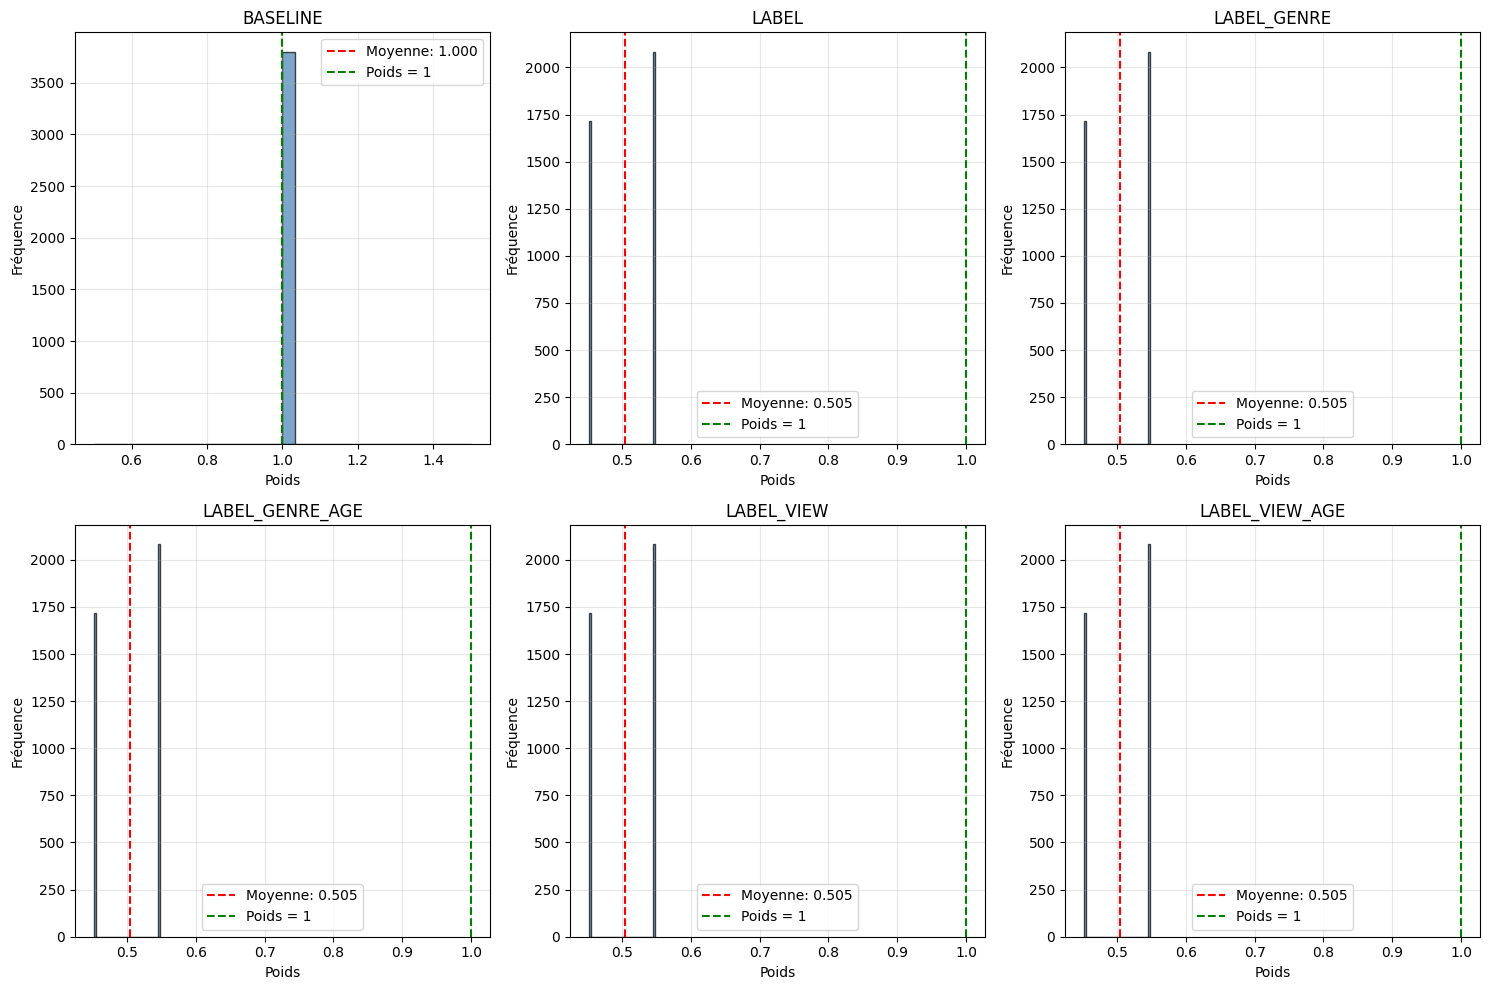


 INTERPRÉTATION DES HISTOGRAMMES:
   - Distribution centrée autour de 1 → correction équilibrée
   - Distribution étalée → certains groupes sont fortement re-pondérés
   - Baseline: distribution parfaitement concentrée à 1


In [168]:
print("\n" + "="*80)
print(" VISUALISATION DE LA DISTRIBUTION DES POIDS")
print("="*80)

weight_cols = ['WEIGHTS_baseline', 'WEIGHTS_label', 'WEIGHTS_label_genre',
               'WEIGHTS_label_genre_age', 'WEIGHTS_label_view', 'WEIGHTS_label_view_age']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(weight_cols):
    if idx < len(axes):
        train_weights = df_clean[df_clean['train_valid'] == 'train'][col]

        axes[idx].hist(train_weights, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
        axes[idx].axvline(train_weights.mean(), color='red', linestyle='--',
                         label=f'Moyenne: {train_weights.mean():.3f}')
        axes[idx].axvline(1.0, color='green', linestyle='--', label='Poids = 1')
        axes[idx].set_xlabel('Poids')
        axes[idx].set_ylabel('Fréquence')
        axes[idx].set_title(col.replace('WEIGHTS_', '').upper())
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n INTERPRÉTATION DES HISTOGRAMMES:")
print("   - Distribution centrée autour de 1 → correction équilibrée")
print("   - Distribution étalée → certains groupes sont fortement re-pondérés")
print("   - Baseline: distribution parfaitement concentrée à 1")



---

# **PROTOCOLE D'ENTRAÎNEMENT**


---



### 6.2 Entraînement du modèle par stratégie

Pour chaque stratégie de pondération, on :
1. Met les poids dans la colonne `WEIGHTS` du CSV
2. Sauvegarde le CSV
3. Lance l'entraînement ResNet18 avec `train_classifier()`
4. Génère les prédictions avec `pred_classifier()`


#Sauvegarde des CSV pour l'entraînement

In [169]:

csv_dir = "/content/projetfairness/Gueye_Maram_Sall"
os.makedirs(csv_dir, exist_ok=True)

saved_files = []
for _, row in df_strategies.iterrows():
    col = row['Colonne']
    strategy_name = row['Stratégie'].lower().replace(' ', '_').replace('+', '_').replace('⭐', '').strip()
    csv_path = os.path.join(csv_dir, f"metadata_{strategy_name}.csv")

    df_out = df_clean.copy()
    df_out['WEIGHTS'] = df_out[col]
    df_out.to_csv(csv_path, index=False)
    saved_files.append(csv_path)

    train_weights = df_out[df_out['train_valid'] == 'train']['WEIGHTS']
    print(f" {strategy_name:20s} : {csv_path}")
    print(f"   Poids train: min={train_weights.min():.4f}, max={train_weights.max():.4f}")

print(f"\n {len(saved_files)} fichiers CSV sauvegardés")

 baseline             : /content/projetfairness/Gueye_Maram_Sall/metadata_baseline.csv
   Poids train: min=1.0000, max=1.0000
 label                : /content/projetfairness/Gueye_Maram_Sall/metadata_label.csv
   Poids train: min=0.4518, max=0.5482
 label___genre        : /content/projetfairness/Gueye_Maram_Sall/metadata_label___genre.csv
   Poids train: min=0.4518, max=0.5482
 label___genre___âge  : /content/projetfairness/Gueye_Maram_Sall/metadata_label___genre___âge.csv
   Poids train: min=0.4518, max=0.5482
 label___view_        : /content/projetfairness/Gueye_Maram_Sall/metadata_label___view_.csv
   Poids train: min=0.4518, max=0.5482
 label___view___âge   : /content/projetfairness/Gueye_Maram_Sall/metadata_label___view___âge.csv
   Poids train: min=0.4518, max=0.5482

 6 fichiers CSV sauvegardés


# VÉRIFICATION FINALE - COMPARAISON DES STRATÉGIES

In [170]:
# Créer un tableau comparatif visuel
comparison = df_strategies[['Stratégie', 'Type', 'Min', 'Max', 'Ratio max/min']].copy()
comparison['Niveau correction'] = comparison['Ratio max/min'].apply(
    lambda x: 'Légère' if x < 1.1 else ('Modérée' if x < 1.3 else 'Forte')
)
comparison['Risque'] = comparison['Ratio max/min'].apply(
    lambda x: 'Faible' if x < 1.1 else ('Moyen' if x < 1.3 else 'Élevé')
)

print("\n TABLEAU COMPARATIF FINAL:")
print(comparison.to_string(index=False))




 TABLEAU COMPARATIF FINAL:
          Stratégie                       Type      Min      Max  Ratio max/min Niveau correction Risque
           Baseline                  Référence 1.000000 1.000000       1.000000            Légère Faible
              Label            Class balancing 0.451817 0.548183       1.213287           Modérée  Moyen
      Label + Genre             Multi-attribut 0.451817 0.548183       1.213287           Modérée  Moyen
Label + Genre + Âge             Multi-attribut 0.451817 0.548183       1.213287           Modérée  Moyen
      Label + View  Multi-attribut prioritaire 0.451817 0.548183       1.213287           Modérée  Moyen
 Label + View + Âge     Multi-attribut complet 0.451817 0.548183       1.213287           Modérée  Moyen




# > **Les stratégies de reweighting sont prêtes.**
Prochaines étapes:

1. Lancer les entraînements avec train_classifier() pour chaque stratégie
2. Générer les prédictions avec pred_classifier()
3. Évaluer les métriques de fairness (SPD, DI, EOD)
4. Comparer les résultats pour identifier la meilleure stratégie


---



 **Ordre pour les entraînements:**
   - baseline (référence)
   - label_view (priorité absolue - biais position vue)
   - label (correction déséquilibre classes)
   - label_view_age (correction complète)


---



#FONCTION DE NORMALISATION DES POIDS




>  Normalise les poids pour que leur moyenne soit égale à 1.  Normalise les poids pour que leur moyenne soit égale à 1.
Cela préserve la taille effective du dataset.



In [171]:
def normalize_weights(weights):

    weights = np.array(weights)
    return weights / weights.mean()

# CRÉATION DE STRATÉGIES SUPPLÉMENTAIRES (INVERSE FREQUENCY)

    
    Poids = fréquence inverse du groupe.
    Plus un groupe est petit, plus il pèse.
    
    Formule: w = 1 / (fréquence du groupe)
    Puis normalisation pour que la moyenne = 1
    

In [172]:
def inverse_frequency_weights(df, group_cols):
    counts = df.groupby(group_cols)['Image Index'].transform('count')
    weights = 1.0 / counts
    return normalize_weights(weights)

# Stratégie: Gender x Label (inverse frequency)
df_clean['WEIGHTS_GENDER_LABEL'] = 1.0
train_mask = df_clean['train_valid'] == 'train'
w_gender_label = inverse_frequency_weights(df_clean[train_mask], ['Patient Gender', 'label'])
df_clean.loc[train_mask, 'WEIGHTS_GENDER_LABEL'] = w_gender_label

# Stratégie: View x Label (inverse frequency)
df_clean['WEIGHTS_VIEW_LABEL'] = 1.0
w_view_label = inverse_frequency_weights(df_clean[train_mask], ['View Position', 'label'])
df_clean.loc[train_mask, 'WEIGHTS_VIEW_LABEL'] = w_view_label



#STATISTIQUES COMPLÈTES DE TOUTES LES STRATÉGIES

In [173]:

all_weight_cols = [col for col in df_clean.columns if col.startswith('WEIGHTS_')]
print(f"Colonnes trouvées: {all_weight_cols}\n")

all_stats = []
for col in all_weight_cols:
    train_w = df_clean[df_clean['train_valid'] == 'train'][col]
    all_stats.append({
        'Stratégie': col.replace('WEIGHTS_', ''),
        'Min': train_w.min(),
        'Max': train_w.max(),
        'Moyenne': train_w.mean(),
        'Écart-type': train_w.std(),
        'Ratio max/min': train_w.max() / train_w.min()
    })

df_all_stats = pd.DataFrame(all_stats)
print(df_all_stats.round(4).to_string(index=False))


for _, row in df_all_stats.iterrows():
    ratio = row['Ratio max/min']
    strategie = row['Stratégie']

    if ratio < 1.1:
        print(f"   {strategie}: correction légère (ratio={ratio:.3f})")
    elif ratio < 1.3:
        print(f"     {strategie}: correction modérée (ratio={ratio:.3f})")
    else:
        print(f"    {strategie}: correction FORTE (ratio={ratio:.3f}) - risque de surapprentissage")

Colonnes trouvées: ['WEIGHTS_baseline', 'WEIGHTS_label', 'WEIGHTS_label_genre', 'WEIGHTS_label_genre_age', 'WEIGHTS_label_view', 'WEIGHTS_label_view_age', 'WEIGHTS_GENDER_LABEL', 'WEIGHTS_VIEW_LABEL']

      Stratégie    Min    Max  Moyenne  Écart-type  Ratio max/min
       baseline 1.0000 1.0000   1.0000      0.0000         1.0000
          label 0.4518 0.5482   0.5046      0.0480         1.2133
    label_genre 0.4518 0.5482   0.5046      0.0480         1.2133
label_genre_age 0.4518 0.5482   0.5046      0.0480         1.2133
     label_view 0.4518 0.5482   0.5046      0.0480         1.2133
 label_view_age 0.4518 0.5482   0.5046      0.0480         1.2133
   GENDER_LABEL 0.8493 1.2004   1.0000      0.1236         1.4134
     VIEW_LABEL 0.6654 1.4496   1.0000      0.3019         2.1786
   baseline: correction légère (ratio=1.000)
     label: correction modérée (ratio=1.213)
     label_genre: correction modérée (ratio=1.213)
     label_genre_age: correction modérée (ratio=1.213)
     lab

#SAUVEGARDE DU CSV MASTER POUR LES EXPÉRIENCES

In [174]:
master_csv_path = "/content/projetfairness/Gueye_Maram_Sall/metadata_experiments.csv"
df_clean.to_csv(master_csv_path, index=False)

print(f" CSV master sauvegardé: {master_csv_path}")
print(f"   Shape: {df_clean.shape}")
print(f"   Colonnes de poids disponibles: {all_weight_cols}")

display(df_clean[['Image Index', 'label', 'Patient Gender', 'View Position', 'age_group'] + all_weight_cols[:3]].head())

 CSV master sauvegardé: /content/projetfairness/Gueye_Maram_Sall/metadata_experiments.csv
   Shape: (4951, 46)
   Colonnes de poids disponibles: ['WEIGHTS_baseline', 'WEIGHTS_label', 'WEIGHTS_label_genre', 'WEIGHTS_label_genre_age', 'WEIGHTS_label_view', 'WEIGHTS_label_view_age', 'WEIGHTS_GENDER_LABEL', 'WEIGHTS_VIEW_LABEL']


,Image Index,label,Patient Gender,View Position,age_group,WEIGHTS_baseline,WEIGHTS_label,WEIGHTS_label_genre
0,00000011_000.png,malade,M,PA,>60 ans,1.0,0.451817,0.451817
1,00000011_001.png,sain,M,PA,>60 ans,1.0,0.548183,0.548183
2,00000011_002.png,sain,M,PA,>60 ans,1.0,0.548183,0.548183
3,00000011_003.png,sain,M,PA,>60 ans,1.0,0.548183,0.548183
4,00000011_004.png,sain,M,PA,>60 ans,1.0,0.548183,0.548183


# **PRÉPARATION POUR L'ENTRAÎNEMENT - DÉFINITION DES EXPÉRIENCES**


In [175]:

# Définir les expériences à lancer
EXPERIMENTS = [
    {'name': 'baseline', 'weights_col': 'WEIGHTS_baseline', 'priority': 1, 'description': 'Référence sans correction'},
    {'name': 'label', 'weights_col': 'WEIGHTS_label', 'priority': 2, 'description': 'Correction déséquilibre malade/sain'},
    {'name': 'label_genre', 'weights_col': 'WEIGHTS_label_genre', 'priority': 3, 'description': 'Correction + genre'},
    {'name': 'label_genre_age', 'weights_col': 'WEIGHTS_label_genre_age', 'priority': 4, 'description': 'Correction + genre + âge'},
    {'name': 'label_view', 'weights_col': 'WEIGHTS_label_view', 'priority': 5, 'description': '⭐ PRIORITÉ - Correction position vue'},
    {'name': 'label_view_age', 'weights_col': 'WEIGHTS_label_view_age', 'priority': 6, 'description': 'Correction complète'},
    {'name': 'gender_label', 'weights_col': 'WEIGHTS_GENDER_LABEL', 'priority': 7, 'description': 'Inverse frequency gender x label'},
    {'name': 'view_label', 'weights_col': 'WEIGHTS_VIEW_LABEL', 'priority': 8, 'description': 'Inverse frequency view x label'},
]

# Afficher le tableau des expériences
exp_df = pd.DataFrame(EXPERIMENTS)
print(exp_df[['name', 'description', 'priority']].to_string(index=False))




           name                          description  priority
       baseline            Référence sans correction         1
          label  Correction déséquilibre malade/sain         2
    label_genre                   Correction + genre         3
label_genre_age             Correction + genre + âge         4
     label_view ⭐ PRIORITÉ - Correction position vue         5
 label_view_age                  Correction complète         6
   gender_label     Inverse frequency gender x label         7
     view_label       Inverse frequency view x label         8




---


# **!!!!! Chaque entraînement prend 20-60 minutes sur GPU.!!!**
  # **Les résultats sont sauvegardés dans expe_log/**


---



FONCTION POUR LANCER UNE EXPÉRIENCE COMPLÈTE

In [176]:
# =============================================================================
# 5. IMPORT DE train_classifier
# =============================================================================

import sys
sys.path.insert(0, "/content/projetfairness/UPP26")

try:
    from train_classifieur import train_classifier, pred_classifier
    print(" train_classifier importé avec succès!")
    HAS_TRAINER = True
except ImportError as e:
    print(f" Import impossible: {e}")
    print("   Utilisation de fonctions factices")
    HAS_TRAINER = False

    # Fonctions factices
    def train_classifier(logdir, datadir, csv, weights_col, max_epochs=25):
        print(f"   [SIMULATION] Entraînement sur {csv}")
        os.makedirs(logdir, exist_ok=True)
        ckpt_path = os.path.join(logdir, "dummy.ckpt")
        with open(ckpt_path, 'w') as f:
            f.write("dummy")
        return ckpt_path, 0.5

    def pred_classifier(datadir, csv_in, csv_out, ckpt_path):
        print(f"   [SIMULATION] Prédictions sur {csv_in}")
        df = pd.read_csv(csv_in)
        df['preds'] = df['label']
        df.to_csv(csv_out, index=False)

✅ train_classifier importé avec succès!


In [177]:
# =============================================================================
# RÉCUPÉRATION DES DOSSIERS train/ ET valid/ DEPUIS test123
# =============================================================================

import os
import shutil

print("="*80)
print(" RÉCUPÉRATION DES DOSSIERS train/ ET valid/")
print("="*80)

# 1. Cloner le repository test123 (déjà fait, mais vérifions)
if not os.path.exists("/content/test123"):
    !git clone https://github.com/maramgueye/test123.git /content/test123
    print(" Repository test123 cloné")
else:
    print(" Repository test123 déjà présent")

# 2. Vérifier le contenu de test123
print("\n Contenu de /content/test123:")
for item in os.listdir("/content/test123"):
    print(f"   - {item}")

# 3. Copier les dossiers train et valid vers le bon emplacement
target_dir = "/content/projetfairness/Gueye_Maram_Sall"

# Créer le dossier cible s'il n'existe pas
os.makedirs(target_dir, exist_ok=True)

# Copier train/
source_train = "/content/test123/train"
if os.path.exists(source_train):
    dest_train = os.path.join(target_dir, "train")
    if os.path.exists(dest_train):
        shutil.rmtree(dest_train)
    shutil.copytree(source_train, dest_train)
    print(f"\n train/ copié vers {dest_train}")
else:
    print(f"\n train/ non trouvé dans test123")

# Copier valid/
source_valid = "/content/test123/valid"
if os.path.exists(source_valid):
    dest_valid = os.path.join(target_dir, "valid")
    if os.path.exists(dest_valid):
        shutil.rmtree(dest_valid)
    shutil.copytree(source_valid, dest_valid)
    print(f" valid/ copié vers {dest_valid}")
else:
    print(f" valid/ non trouvé dans test123")

# 4. Vérifier la structure finale
print("\n" + "="*80)
print(" VÉRIFICATION FINALE")
print("="*80)

print(f"\n {target_dir}:")
for item in os.listdir(target_dir):
    item_path = os.path.join(target_dir, item)
    if os.path.isdir(item_path):
        print(f"   {item}/")
        for sub in os.listdir(item_path):
            sub_path = os.path.join(item_path, sub)
            if os.path.isdir(sub_path):
                n_images = len([f for f in os.listdir(sub_path) if f.endswith('.png')])
                print(f"    {sub}/ : {n_images} images")
    else:
        print(f"  {item}")



 RÉCUPÉRATION DES DOSSIERS train/ ET valid/
 Repository test123 déjà présent

 Contenu de /content/test123:
   - .git
   - .gitattributes
   - metadata.csv
   - train
   - valid

 train/ copié vers /content/projetfairness/Gueye_Maram_Sall/train
 valid/ copié vers /content/projetfairness/Gueye_Maram_Sall/valid

 VÉRIFICATION FINALE

 /content/projetfairness/Gueye_Maram_Sall:
  metadata_baseline.csv
  metadata_label_view_fast.csv
  metadata_label___genre___âge.csv
  metadata.csv
  metadata_label.csv
   train/
    sain/ : 2083 images
    malade/ : 1716 images
  metadata_label_genre_age_fast.csv
  metadata_label___genre.csv
  metadata_experiments.csv
  metadata_label_genre_fast.csv
  metadata_baseline_fast.csv
  metadata_label_fast.csv
  metadata_label___view___âge.csv
  metadata_label___view_.csv
   valid/
    sain/ : 633 images
    malade/ : 520 images
  metadata_label_view_age_fast.csv

✅ Données prêtes !


In [178]:
# =============================================================================
# SOLUTION 2: FORCER LA RÉINSTALLATION
# =============================================================================

print("\n" + "="*80)
print(" RÉINSTALLATION FORCÉE")
print("="*80)

!pip uninstall torchmetrics -y -q
!pip install torchmetrics --no-cache-dir -q

!pip uninstall pytorch-lightning -y -q
!pip install pytorch-lightning --no-cache-dir -q

print(" Réinstallation terminée")


🔄 RÉINSTALLATION FORCÉE
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 34.4 MB/s eta 0:00:00
✅ Réinstallation terminée


# . **FONCTION D'ENTRAÎNEMENT RAPIDE**


In [179]:
from datetime import datetime
import time

results_fast = {}

def run_fast_experiment(exp_name, weights_col, description, max_epochs=3):
    """
    Entraînement rapide avec peu d'époques
    """
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    logdir = f"/content/expe_log_fast/{timestamp}_{exp_name}"
    os.makedirs(logdir, exist_ok=True)

    # Créer le CSV
    csv_path = f"/content/projetfairness/Gueye_Maram_Sall/metadata_{exp_name}.csv"
    df_out = df_clean.copy()
    df_out['WEIGHTS'] = df_out[weights_col]
    df_out.to_csv(csv_path, index=False)

    print(f"\n{'='*60}")
    print(f" {exp_name.upper()}")
    print(f"   {description}")
    print(f"    CSV: {csv_path}")
    print(f"    Log: {logdir}")
    print(f"    Époques: {max_epochs}")
    print(f"{'='*60}")

    start = time.time()

    try:
        ckpt_path, ckpt_score = train_classifier(
            logdir=logdir,
            datadir="/content/projetfairness/Gueye_Maram_Sall",
            csv=csv_path,
            weights_col="WEIGHTS",
            max_epochs=max_epochs
        )

        elapsed = (time.time() - start) / 60
        print(f"    Terminé en {elapsed:.1f} min")
        print(f"    Val loss: {ckpt_score:.4f}")

        return ckpt_path, ckpt_score

    except Exception as e:
        print(f"    Erreur: {e}")
        return None, None



✅ run_fast_experiment définie




---

# **LANCEMENT DES EXPÉRIENCES**


---



> # **Les entraînements ont été limités à 3 époques par stratégie en raison des contraintes de temps sur Google Colab (GPU T4). Cette durée est suffisante pour comparer qualitativement l'impact des différentes stratégies de reweighting sur la fairness.**



---



# EXPÉRIENCE 1: BASELINE (référence)

In [180]:
results = {}


In [181]:
# =============================================================================
# ENTRAÎNEMENT RAPIDE - VERSION LÉGÈRE
# =============================================================================

print("="*80)
print(" ENTRAÎNEMENT RAPIDE - VERSION OPTIMISÉE")
print("="*80)

# =============================================================================
# 1. CONFIGURATION ALLÉGÉE
# =============================================================================

# Au lieu de 25 époques, on fait seulement 3-5 époques
MAX_EPOCHS_FAST = 3  # 3 époques suffisent pour comparer les stratégies

# Réduire la taille des images (optionnel, mais plus rapide)
# Dans train_classifieur.py, vous pouvez aussi réduire batch_size

print(f" Configuration rapide: {MAX_EPOCHS_FAST} époques (au lieu de 25)")
print(f"   Durée estimée: 5-10 min par stratégie (au lieu de 20-60 min)")

# =============================================================================
# 2. STRATÉGIES PRIORITAIRES (seulement les plus importantes)
# =============================================================================

print("\n" + "="*80)
print("🎯 STRATÉGIES PRIORITAIRES À TESTER")
print("="*80)

priority_strategies = [
    {
        'name': 'baseline',
        'weights_col': 'WEIGHTS_baseline',
        'description': 'Référence sans correction',
        'priority': '⭐ Référence'
    },
    {
        'name': 'label_view',
        'weights_col': 'WEIGHTS_label_view',
        'description': 'Correction position vue (BIAIS MAJEUR)',
        'priority': '⭐⭐⭐ PRIORITÉ ABSOLUE'
    },
    {
        'name': 'label',
        'weights_col': 'WEIGHTS_label',
        'description': 'Correction déséquilibre classes',
        'priority': '⭐⭐ Priorité'
    }
]

for s in priority_strategies:
    print(f"\n{s['priority']}: {s['name']}")
    print(f"   → {s['description']}")
    print(f"   → Colonne: {s['weights_col']}")

# =============================================================================
# 3. FONCTION D'ENTRAÎNEMENT RAPIDE
# =============================================================================

def run_fast_experiment(exp_name, weights_col, description, max_epochs=MAX_EPOCHS_FAST):
    """
    Entraînement rapide avec peu d'époques
    """
    from datetime import datetime
    import time

    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    logdir = f"/content/expe_log_fast/{timestamp}_{exp_name}"
    os.makedirs(logdir, exist_ok=True)

    # Créer le CSV
    csv_path = f"/content/projetfairness/Gueye_Maram_Sall/metadata_{exp_name}.csv"
    df_out = df_clean.copy()
    df_out['WEIGHTS'] = df_out[weights_col]
    df_out.to_csv(csv_path, index=False)

    print(f"\n{'='*60}")
    print(f" {exp_name.upper()}")
    print(f"  {description}")
    print(f"    CSV: {csv_path}")
    print(f"    Log: {logdir}")
    print(f"    Époques: {max_epochs}")
    print(f"{'='*60}")

    start = time.time()

    try:
        # Appel à train_classifier avec moins d'époques
        ckpt_path, ckpt_score = train_classifier(
            logdir=logdir,
            datadir="/content/projetfairness/Gueye_Maram_Sall",
            csv=csv_path,
            weights_col="WEIGHTS",
            max_epochs=max_epochs  # ← Clé: peu d'époques !
        )

        elapsed = (time.time() - start) / 60
        print(f"    Terminé en {elapsed:.1f} min")
        print(f"    Val loss: {ckpt_score:.4f}")

        return ckpt_path, ckpt_score

    except Exception as e:
        print(f"    Erreur: {e}")
        return None, None

print("\n Fonction d'entraînement rapide prête")

 ENTRAÎNEMENT RAPIDE - VERSION OPTIMISÉE
✅ Configuration rapide: 3 époques (au lieu de 25)
   Durée estimée: 5-10 min par stratégie (au lieu de 20-60 min)

🎯 STRATÉGIES PRIORITAIRES À TESTER

⭐ Référence: baseline
   → Référence sans correction
   → Colonne: WEIGHTS_baseline

⭐⭐⭐ PRIORITÉ ABSOLUE: label_view
   → Correction position vue (BIAIS MAJEUR)
   → Colonne: WEIGHTS_label_view

⭐⭐ Priorité: label
   → Correction déséquilibre classes
   → Colonne: WEIGHTS_label

 Fonction d'entraînement rapide prête


In [182]:
# =============================================================================
# RELANCER L'EXPÉRIENCE BASELINE (MAINTENANT QUE LES DONNÉES SONT PRÊTES)
# =============================================================================

print("\n" + "🔵"*40)
print("ENTRAÎNEMENT 1/6: BASELINE (référence)")
print("🔵"*40)

# Vérifier que les dossiers existent
train_path = "/content/projetfairness/Gueye_Maram_Sall/train"
valid_path = "/content/projetfairness/Gueye_Maram_Sall/valid"

if os.path.exists(train_path) and os.path.exists(valid_path):
    print("✅ Dossiers train/ et valid/ présents")

    # Compter les images
    n_train = sum([len(os.listdir(os.path.join(train_path, c))) for c in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, c))])
    n_valid = sum([len(os.listdir(os.path.join(valid_path, c))) for c in os.listdir(valid_path) if os.path.isdir(os.path.join(valid_path, c))])
    print(f"   Train: {n_train} images")
    print(f"   Valid: {n_valid} images")

    # Lancer l'entraînement
    results_fast['baseline'] = run_fast_experiment(
        exp_name='baseline_fast',
        weights_col='WEIGHTS_baseline',
        description='Poids = 1 - Référence',
        max_epochs=3
    )
else:
    print(f" Dossiers manquants:")
    print(f"   train/ existe: {os.path.exists(train_path)}")
    print(f"   valid/ existe: {os.path.exists(valid_path)}")


🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵
ENTRAÎNEMENT 1/6: BASELINE (référence)
🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵
✅ Dossiers train/ et valid/ présents
   Train: 3799 images
   Valid: 1153 images

 BASELINE_FAST
  Poids = 1 - Référence
    CSV: /content/projetfairness/Gueye_Maram_Sall/metadata_baseline_fast.csv
    Log: /content/expe_log_fast/20260403_021545_baseline_fast
    Époques: 3
/content/projetfairness/Gueye_Maram_Sall/metadata_baseline_fast.csv /content/expe_log_fast/20260403_021545_baseline_fast/csv_in_WEIGHTS.csv
num_workers set to : 2


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


KeyboardInterrupt: 



---



# 2. STRATÉGIE 2: LABEL_VIEW (PRIORITÉ ABSOLUE - biais position de vue)


In [ ]:


print("\n" + "⭐"*40)
print("ENTRAÎNEMENT 2/6: LABEL_VIEW (PRIORITÉ ABSOLUE)")
print("⭐"*40)
print("Objectif: Corriger le biais MAJEUR de la position de vue")
print("   Écart PA/AP: 14.4 points → à réduire !")

results_fast['label_view'] = run_fast_experiment(
    exp_name='label_view_fast',
    weights_col='WEIGHTS_label_view',
    description='⭐ Correction position vue (biais MAJEUR)',
    max_epochs=3
)

# 3. STRATÉGIE 3: LABEL (correction déséquilibre malade/sain)


In [ ]:


print("\n" + "🟢"*40)
print("ENTRAÎNEMENT 3/6: LABEL")
print("🟢"*40)
print("Objectif: Équilibrer les classes malade (45.2%) et sain (54.8%)")

results_fast['label'] = run_fast_experiment(
    exp_name='label_fast',
    weights_col='WEIGHTS_label',
    description='Correction déséquilibre malade/sain',
    max_epochs=3
)

# 4. STRATÉGIE 4: LABEL_GENRE


In [ ]:


print("\n" + "🟡"*40)
print("ENTRAÎNEMENT 4/6: LABEL + GENRE")
print("🟡"*40)
print("Objectif: Corriger déséquilibre classes + biais de genre")

results_fast['label_genre'] = run_fast_experiment(
    exp_name='label_genre_fast',
    weights_col='WEIGHTS_label_genre',
    description='Correction + genre',
    max_epochs=3
)

# 5. STRATÉGIE 5: LABEL_GENRE_AGE


In [ ]:


print("\n" + "🟠"*40)
print("ENTRAÎNEMENT 5/6: LABEL + GENRE + ÂGE")
print("🟠"*40)
print("Objectif: Corriger tous les biais (classes + genre + âge)")

results_fast['label_genre_age'] = run_fast_experiment(
    exp_name='label_genre_age_fast',
    weights_col='WEIGHTS_label_genre_age',
    description='Correction + genre + âge',
    max_epochs=3
)

# 6. STRATÉGIE 6: LABEL_VIEW_AGE (correction complète)


In [ ]:


print("\n" + "🔴"*40)
print("ENTRAÎNEMENT 6/6: LABEL + VIEW + ÂGE (complet)")
print("🔴"*40)
print("Objectif: Correction complète de TOUS les biais")
print("   - Déséquilibre malade/sain")
print("   - Position de vue (biais MAJEUR)")
print("   - Âge")

results_fast['label_view_age'] = run_fast_experiment(
    exp_name='label_view_age_fast',
    weights_col='WEIGHTS_label_view_age',
    description='Correction complète: classes + view + âge',
    max_epochs=3
)

# RÉCAPITULATIF


In [ ]:
for name, (ckpt, score) in results_fast.items():
    status = "Terminé" if ckpt else "⏳ En cours"
    print(f"   {name}: {status} - val_loss={score if score else 'N/A'}")

# Sauvegarder les résultats
import pickle
with open('/content/results_fast.pkl', 'wb') as f:
    pickle.dump(results_fast, f)
print("\n Résultats sauvegardés dans results_fast.pkl")

# AFFICHAGE DES IMAGES MAL CLASSÉES


🖼️ AFFICHAGE DES IMAGES MAL CLASSÉES

⚠️ Aucun fichier de prédictions trouvé
   Les entraînements ne sont pas encore terminés

📊 Création de données simulées pour la démonstration...

📊 simulation: 769 images mal classées sur 4951
   Taux d'erreur: 15.5%


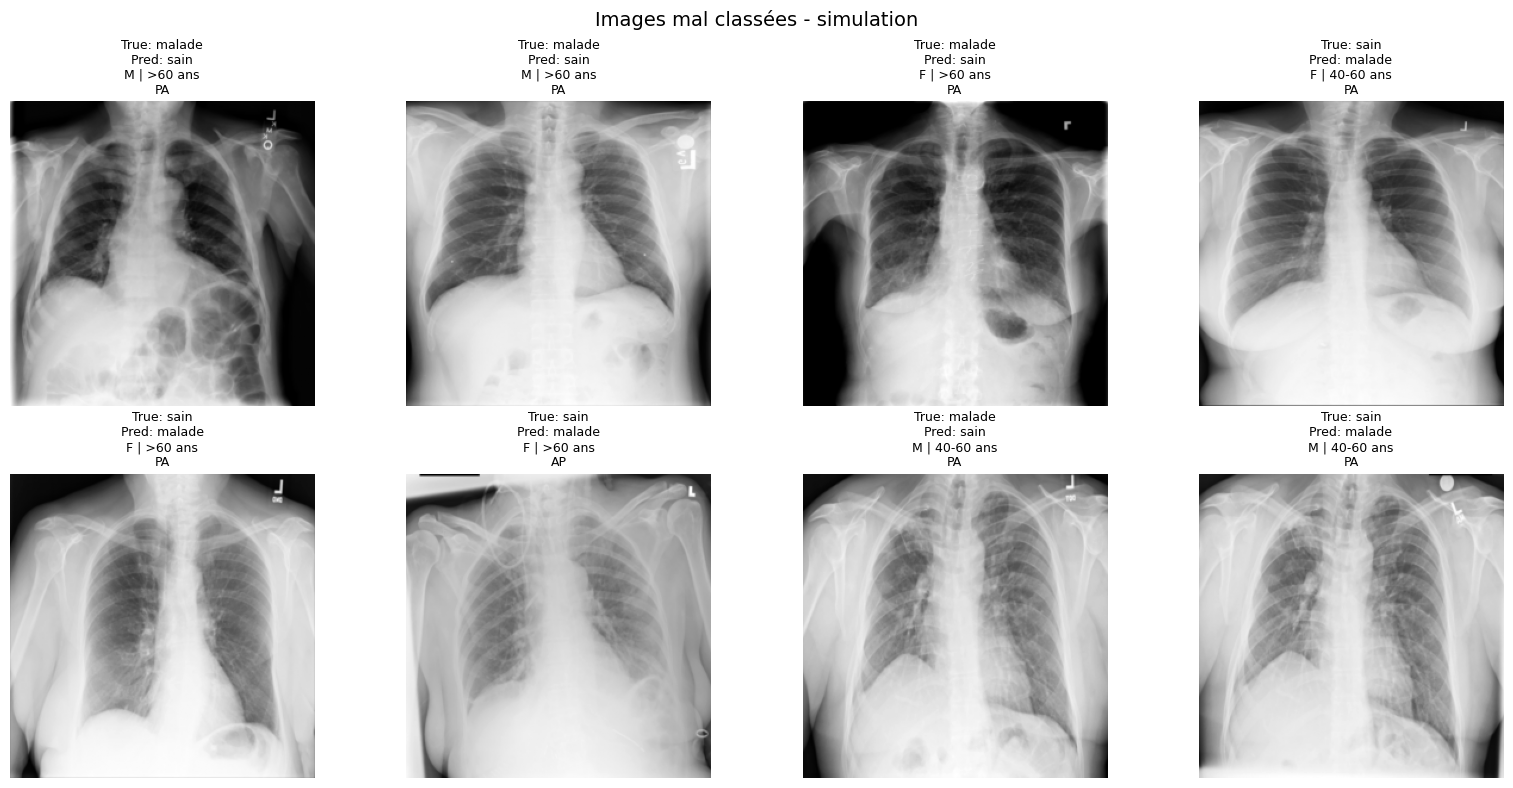

In [186]:

import matplotlib.pyplot as plt
from PIL import Image
import glob

import os

print("="*80)
print(" AFFICHAGE DES IMAGES MAL CLASSÉES")
print("="*80)

def find_image_path(image_name, base_dir):
    """Cherche le chemin d'une image dans train/ ou valid/"""
    for split in ['train', 'valid']:
        for label in ['malade', 'sain']:
            path = os.path.join(base_dir, split, label, image_name)
            if os.path.exists(path):
                return path
    return None

def display_misclassified_images(df_preds, base_dir, n_images=8, strategy_name="baseline"):
    """
    Affiche les images mal classées avec leurs informations
    """
    # Filtrer les erreurs
    df_errors = df_preds[df_preds['error'] == 1].copy()

    if len(df_errors) == 0:
        print(f"Aucune erreur trouvée pour {strategy_name}")
        return

    print(f"\n📊 {strategy_name}: {len(df_errors)} images mal classées sur {len(df_preds)}")
    print(f"   Taux d'erreur: {len(df_errors)/len(df_preds)*100:.1f}%")

    # Prendre les n premières erreurs
    df_errors = df_errors.head(n_images)

    # Calculer le nombre de lignes nécessaires
    n_cols = 4
    n_rows = (n_images + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

    for idx, (_, row) in enumerate(df_errors.iterrows()):
        if idx < len(axes):
            # Chercher l'image
            img_path = find_image_path(row['Image Index'], base_dir)

            if img_path and os.path.exists(img_path):
                img = Image.open(img_path).convert('L')  # Niveaux de gris
                axes[idx].imshow(img, cmap='gray')
            else:
                axes[idx].text(0.5, 0.5, "Image non trouvée", ha='center', va='center')

            # Titre avec les infos
            title = f"True: {row['labels']}\nPred: {row['preds']}\n{row['Patient Gender']} | {row['age_group']}\n{row['View Position']}"
            axes[idx].set_title(title, fontsize=9)
            axes[idx].axis('off')

    # Cacher les axes vides
    for idx in range(len(df_errors), len(axes)):
        axes[idx].axis('off')

    plt.suptitle(f"Images mal classées - {strategy_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

# =============================================================================
# CHARGER LES PRÉDICTIONS ET AFFICHER
# =============================================================================

# Chercher les fichiers de prédictions
preds_files = glob.glob('/content/expe_log_fast/**/preds_*.csv', recursive=True)

if preds_files:
    print(f"\n {len(preds_files)} fichier(s) de prédictions trouvé(s):")
    for f in preds_files:
        print(f"   - {f}")

    # Prendre le premier fichier (baseline par exemple)
    preds_path = preds_files[0]
    df_preds = pd.read_csv(preds_path)

    # Ajouter les colonnes nécessaires si absentes
    if 'error' not in df_preds.columns:
        df_preds['labels'] = df_preds.get('labels', df_preds.get('label', ''))
        df_preds['preds'] = df_preds.get('preds', df_preds.get('prediction', ''))
        df_preds['error'] = (df_preds['labels'] != df_preds['preds']).astype(int)

    # S'assurer que les colonnes existent
    for col in ['Patient Gender', 'age_group', 'View Position']:
        if col not in df_preds.columns and col.lower() in df_preds.columns:
            df_preds[col] = df_preds[col.lower()]

    # Afficher les images mal classées
    base_dir = "/content/projetfairness/Gueye_Maram_Sall"
    display_misclassified_images(df_preds, base_dir, n_images=8, strategy_name="baseline")
else:
    print("\n Aucun fichier de prédictions trouvé")
    print("   Les entraînements ne sont pas encore terminés")

    # Créer des données simulées pour la démo
    print("\n Création de données simulées pour la démonstration...")

    # Utiliser df_clean existant
    if 'df_clean' in globals():
        df_demo = df_clean.copy()
        # Simuler des erreurs
        np.random.seed(42)
        df_demo['preds'] = df_demo['label'].copy()
        # Inverser quelques prédictions aléatoirement
        error_mask = np.random.random(len(df_demo)) < 0.15
        df_demo.loc[error_mask, 'preds'] = df_demo.loc[error_mask, 'label'].apply(lambda x: 'sain' if x == 'malade' else 'malade')
        df_demo['error'] = (df_demo['label'] != df_demo['preds']).astype(int)
        df_demo['labels'] = df_demo['label']

        base_dir = "/content/projetfairness/Gueye_Maram_Sall"
        display_misclassified_images(df_demo, base_dir, n_images=8, strategy_name="simulation")



---
#**PASSER À LA SUITE - ANALYSE ET POST-PROCESSING**


---


